# Transit Anomaly Detection for Airport and Border Control Data

**Machine Learning Project — Academic Year 2025/26**
**Company brief:** Whitehall Reply — Project 2 *(Classical vs Multi-Agent anomaly detection)*

**Team members**    - Giulio D'Amico    - Alexis Mitracos
---

## Project scope

Border-control authorities and airport operators handle large volumes of passenger transits daily, with rich metadata attached to each event (timestamp, gate, route, nationality, document type, control outcome, alert flags). Today, anomaly detection on such data is mostly reactive. The goal of this project is to implement the same anomaly-detection system twice — once as a **classical pipeline** and once as a **multi-agent architecture** — and to produce a comparative analysis identifying the operational conditions under which each approach is preferable.

## Notebook Index

1. Setup and data loading
2. Data-quality audit
3. Univariate analysis
4. Bivariate analysis
5. Multivariate analysis
6. Outlier analysis
7. Cross-dataset coverage
8. Feature engineering
9. Engineered features
10. Feature selection
11. Isolation Forest detector
12. Local Outlier Factor detector
13. Z-score detector and three-way consensus
14. Rule-based post-processing layer
15. Conclusions and next steps


## 1. Setup and data loading

### 1.1 Imports and plotting defaults

We load the scientific stack (`numpy`, `pandas`, `matplotlib`, `seaborn`), `missingno` for missing-value diagnostics, `pycountry` for ISO country-code normalisation, and `re` for the regex-based date parsing used in the cleaning block. Plotting defaults are set globally so that every figure in the notebook shares the same style.


In [527]:
import time
import warnings, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import pycountry
from sklearn.preprocessing import StandardScaler
from IPython.display import display
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.cluster import DBSCAN
from scipy import stats

CONTAMINATION = 0.05
start_time = time.time()
# Global plotting defaults
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05, palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.2f}".format)

# Project palette
NAVY, STEEL, CORAL, GREEN, BLACK, RED, GOLD, LIGHTBLUE, BROWN, ROSE = "#1A3764", "#4682B4", "#E8735A", "#27AE60", "#000000", "#E74C3C", "#F1C40F", "#A2D2FF", "#8B4513", "#FF69B4"
PALETTE = [NAVY, STEEL, CORAL, GREEN, BLACK, RED, GOLD, LIGHTBLUE, BROWN, ROSE]

# Reproducibility
RANDOM_STATE = 42

### 1.2 Reference mappings

The raw CSVs come in Italian, with inconsistent casing, typographic errors (e.g. `AREOPORTO`), and a mixture of Italianised and English spellings for countries, cities and airports. To feed the downstream pipeline with a clean English `snake_case` schema we rely on four curated dictionaries:

- `manual_mapping` — IT to EN column-name mapping; disambiguates duplicated columns (e.g. `Tipo_Documento` and `TIPO_DOCUMENTO` become `document_type` and `document_type2`) that are reconciled in section 2.3.
- `it_to_en` — Italian to English country names; consumed by `pycountry` to emit the ISO alpha-3 code of every departure country. Kosovo, which has no official ISO code, is hand-coded as `RKS`.
- `city_mapping` — Italianised city names mapped to their canonical English spelling.
- `iata_mapping` — a curated `IATA -> {city, airport}` lookup, used to back-fill missing city and airport descriptions in the Alarms dataset when the IATA column is populated but the free-text fields are not.
- `occurrences_map` — a mapping of the `OCCURRENCES` column in the Alarms dataset, which contains a mixture of numeric values and categorical labels (e.g. `>5`), to a clean numeric format that can be fed to the anomaly detectors.

All four dictionaries are embedded in the notebook (rather than imported from a configuration module) so that the notebook is fully self-contained, as required by the submission guidelines.


In [528]:
iata_mapping = {
    'ABJ': ('Abidjan', 'Felix Houphouet Boigny'),
    'ADB': ('Izmir', 'Adnan Menderes'),
    'ADD': ('Addis Ababa', 'Bole International'),
    'ADL': ('Adelaide', 'Adelaide International'),
    'AER': ('Sochi', 'Sochi International'),
    'AKL': ('Auckland', 'Auckland International'),
    'ALA': ('Almaty', 'Almaty International'),
    'ALG': ('Algiers', 'Houari Boumediene'),
    'AMD': ('Ahmedabad', 'Ahmedabad'),
    'AMM': ('Amman', 'Queen Alia International'),
    'ARN': ('Stockholm', 'Stockholm Arlanda'),
    'ASB': ('Ashgabat', 'Ashgabat'),
    'ASM': ('Asmara', 'Asmara International'),
    'ATL': ('Atlanta', 'Hartsfield-Jackson Atlanta International'),
    'AUH': ('Abu Dhabi', 'Abu Dhabi International'),
    'AYT': ('Antalya', 'Antalya'),
    'BAH': ('Manama', 'Bahrain International'),
    'BEG': ('Belgrade', 'Nikola Tesla'),
    'BEY': ('Beirut', 'Beirut-Rafic Hariri International'),
    'BFS': ('Belfast', 'Belfast International'),
    'BHX': ('Birmingham', 'Birmingham International'),
    'BKK': ('Bangkok', 'Suvarnabhumi International'),
    'BLR': ('Bangalore', 'Bangalore International'),
    'BNA': ('Nashville', 'Nashville International'),
    'BNE': ('Brisbane', 'Brisbane International'),
    'BOG': ('Bogota', 'Eldorado International'),
    'BOS': ('Boston', 'Logan International'),
    'BRS': ('Bristol', 'Bristol Airport'),
    'BSB': ('Brasilia', 'Presidente Juscelino Kubitschek'),
    'BUF': ('Buffalo', 'Buffalo Niagara International'),
    'CAI': ('Cairo', 'Cairo International'),
    'CAN': ('Guangzhou', 'Guangzhou Baiyun International'),
    'CEB': ('Cebu', 'Mactan-Cebu International'),
    'CGK': ('Jakarta', 'Soekarno-Hatta International'),
    'CLE': ('Cleveland', 'Hopkins International'),
    'CMN': ('Casablanca', 'Mohammed V International'),
    'CUN': ('Cancun', 'Cancun International'),
    'CVG': ('Cincinnati', 'Cincinnati/Northern Kentucky'),
    'DAR': ('Dar Es Salaam', 'Julius Nyerere International'),
    'DEL': ('New Delhi', 'Indira Gandhi International'),
    'DFW': ('Dallas-Fort Worth', 'Dallas/Fort Worth International'),
    'DMM': ('Dammam', 'King Fahd International'),
    'DOH': ('Doha', 'Hamad International'),
    'DPS': ('Denpasar', 'Ngurah Rai International'),
    'DSS': ('Dakar', 'Blaise Diagne International'),
    'DTW': ('Detroit', 'Detroit Metropolitan Wayne County'),
    'DUR': ('Durban', 'King Shaka International'),
    'DWC': ('Dubai', 'Al Maktoum International'),
    'DXB': ('Dubai', 'Dubai International'),
    'EDI': ('Edinburgh', 'Edinburgh Airport'),
    'ELQ': ('Buraidah', 'Gassim Regional'),
    'EMA': ('Derby', 'East Midlands'),
    'ESB': ('Ankara', 'Esenboga'),
    'EVN': ('Yerevan', 'Zvartnots International'),
    'EWR': ('Newark', 'Newark Liberty International'),
    'EZE': ('Buenos Aires', 'Ezeiza Ministro Pistarini'),
    'FEZ': ('Fes', 'Fes-Saiss'),
    'FIH': ('Kinshasa', "N'Djili International"),
    'FLL': ('Fort Lauderdale', 'Fort Lauderdale/Hollywood International'),
    'FRA': ('Frankfurt', 'Frankfurt International'),
    'FRU': ('Bishkek', 'Manas'),
    'FUK': ('Fukuoka', 'Fukuoka'),
    'GIG': ('Rio de Janeiro', 'Galeao-Antonio Carlos Jobim International'),
    'GLA': ('Glasgow', 'Glasgow International'),
    'GRU': ('Sao Paulo', 'Sao Paulo/Guarulhos International'),
    'GYD': ('Baku', 'Heydar Aliyev International'),
    'GZT': ('Gaziantep', 'Gaziantep'),
    'HAN': ('Hanoi', 'Noibai International'),
    'HGH': ('Hangzhou', 'Hangzhou Xiaoshan International'),
    'HKG': ('Hong Kong', 'Hong Kong International'),
    'HKT': ('Phuket', 'Phuket International'),
    'HND': ('Tokyo', 'Tokyo Haneda International'),
    'HRG': ('Hurghada', 'Hurghada International'),
    'IAD': ('Washington', 'Washington Dulles International'),
    'IAH': ('Houston', 'George Bush Intercontinental'),
    'ICN': ('Seoul', 'Incheon International'),
    'IFN': ('Isfahan', 'Isfahan International'),
    'IKA': ('Tehran', 'Imam Khomeini International'),
    'ISB': ('Islamabad', 'Islamabad International'),
    'IST': ('Istanbul', 'Istanbul Airport'),
    'JAX': ('Jacksonville', 'Jacksonville International'),
    'JED': ('Jeddah', 'King Abdulaziz International'),
    'JFK': ('New York', 'John F. Kennedy International'),
    'KBL': ('Kabul', 'Khwaja Rawash'),
    'KCH': ('Kuching', 'Kuching International'),
    'KIV': ('Chisinau', 'Chisinau International'),
    'KUL': ('Kuala Lumpur', 'Kuala Lumpur International'),
    'KUT': ('Kutaisi', 'Kutaisi International'),
    'KWI': ('Kuwait City', 'Kuwait International'),
    'KZN': ('Kazan', 'Kazan International'),
    'LAD': ('Luanda', '4 de Fevereiro'),
    'LAS': ('Las Vegas', 'McCarran International'),
    'LAX': ('Los Angeles', 'Los Angeles International'),
    'LCY': ('London', 'London City'),
    'LGW': ('London', 'London Gatwick'),
    'LHR': ('London', 'London Heathrow'),
    'LOS': ('Lagos', 'Murtala Muhammed'),
    'LPL': ('Liverpool', 'Liverpool John Lennon'),
    'LRM': ('La Romana', 'Casa de Campo International'),
    'LTN': ('London', 'London Luton'),
    'MAN': ('Manchester', 'Manchester Airport'),
    'MBA': ('Mombasa', 'Moi International'),
    'MCT': ('Muscat', 'Muscat International'),
    'MED': ('Madinah', 'Mohammad Bin Abdulaziz'),
    'MEL': ('Melbourne', 'Melbourne Tullamarine'),
    'MEX': ('Mexico City', 'Benito Juarez International'),
    'MHD': ('Mashad', 'Mashad'),
    'MIA': ('Miami', 'Miami International'),
    'MJI': ('Tripoli', 'Mitiga'),
    'MLE': ('Male', 'Velana International'),
    'MNL': ('Manila', 'Ninoy Aquino International'),
    'MPM': ('Maputo', 'Maputo International'),
    'MRU': ('Plaisance', 'Sir Seewoosagur Ramgoolam International'),
    'MYR': ('Myrtle Beach', 'Myrtle Beach International'),
    'NAV': ('Nevsehir', 'Nevsehir Kapadokya'),
    'NBO': ('Nairobi', 'Jomo Kenyatta International'),
    'NCL': ('Newcastle', 'Newcastle Airport'),
    'NOS': ('Nosy Be', 'Fascene'),
    'NRT': ('Tokyo', 'Narita International'),
    'NSI': ('Yaounde', 'Nsimalen International'),
    'ORD': ('Chicago', "Chicago O'Hare International"),
    'OUA': ('Ouagadougou', 'Ouagadougou'),
    'OXB': ('Bissau', 'Osvaldo Vieira International'),
    'PEK': ('Beijing', 'Beijing Capital International'),
    'PER': ('Perth', 'Perth International'),
    'PEW': ('Peshawar', 'Peshawar'),
    'PHL': ('Philadelphia', 'Philadelphia International'),
    'PKX': ('Beijing', 'Beijing Daxing International'),
    'POA': ('Porto Alegre', 'Salgado Filho'),
    'PRN': ('Pristina', 'Prishtina International'),
    'PVG': ('Shanghai', 'Shanghai Pudong International'),
    'PVR': ('Puerto Vallarta', 'Licenciado Gustavo Diaz Ordaz International'),
    'RAK': ('Marrakech', 'Menara'),
    'REC': ('Recife', 'Guararapes International'),
    'RMF': ('Marsa Alam', 'Marsa Alam International'),
    'RMO': ('Chisinau', 'Chisinau International'),
    'RUH': ('Riyadh', 'King Khaled International'),
    'SAW': ('Istanbul', 'Sabiha Gokcen'),
    'SCL': ('Santiago', 'Arturo Merino Benitez'),
    'SDU': ('Rio de Janeiro', 'Santos Dumont'),
    'SGN': ('Ho Chi Minh City', 'Tan Son Nhat International'),
    'SHJ': ('Sharjah', 'Sharjah International'),
    'SIN': ('Singapore', 'Changi'),
    'SJJ': ('Sarajevo', 'Sarajevo'),
    'SKG': ('Thessaloniki', 'Macedonia International'),
    'SKP': ('Skopje', 'Skopje International'),
    'SKT': ('Sialkot', 'Sialkot International'),
    'SMF': ('Sacramento', 'Sacramento International'),
    'SOF': ('Sofia', 'Sofia'),
    'SPX': ('Giza', 'Sphinx International'),
    'SSA': ('Salvador', 'Luis Eduardo Magalhaes'),
    'SSH': ('Sharm El Sheikh', 'Sharm El-Sheikh International'),
    'STN': ('London', 'London Stansted'),
    'SVO': ('Moscow', 'Sheremetyevo'),
    'SYD': ('Sydney', 'Kingsford Smith'),
    'SYR': ('Syracuse', 'Syracuse Hancock International'),
    'SYZ': ('Shiraz', 'Shiraz'),
    'SZX': ('Shenzhen', 'Shenzhen Baoan International'),
    'TAS': ('Tashkent', 'Tashkent International'),
    'TBS': ('Tbilisi', 'Tbilisi International'),
    'TFU': ('Chengdu', 'Tianfu International'),
    'TGD': ('Podgorica', 'Podgorica Airport'),
    'TIA': ('Tirana', 'Rinas Mother Teresa'),
    'TLV': ('Tel Aviv', 'Ben Gurion International'),
    'TNG': ('Tangier', 'Ibn Battouta'),
    'TPA': ('Tampa', 'Tampa International'),
    'TPE': ('Taipei', 'Taiwan Taoyuan International'),
    'TSA': ('Taipei', 'Taipei Songshan'),
    'TUN': ('Tunis', 'Tunis-Carthage'),
    'VKO': ('Moscow', 'Vnukovo'),
    'YEG': ('Edmonton', 'Edmonton International'),
    'YHZ': ('Halifax', 'Halifax International'),
    'YUL': ('Montreal', 'Montreal-Trudeau International'),
    'YVR': ('Vancouver', 'Vancouver International'),
    'YWG': ('Winnipeg', 'Winnipeg James Armstrong Richardson International'),
    'YYC': ('Calgary', 'Calgary International'),
    'YYZ': ('Toronto', 'Toronto Pearson International'),
    'ZNZ': ('Zanzibar', 'Abeid Amani Karume International'),
    'AGA': ('Agadir',       'Agadir Al Massira'),
    'ANU': ("St. John's",   'V.C. Bird International'),
    'ATQ': ('Amritsar',     'Sri Guru Ram Dass Jee International'),
    'BQH': ('London',       'London Biggin Hill'),
    'CGO': ('Zhengzhou',    'Zhengzhou Xinzheng International'),
    'CKG': ('Chongqing',    'Chongqing Jiangbei International'),
    'FAB': ('Farnborough',  'Farnborough Airport'),
    'ISL': ('Istanbul',     'Ataturk International'),    
    'LBA': ('Leeds',        'Leeds Bradford'),
    'LXR': ('Luxor',        'Luxor International'),
    'LYX': ('Lydd',         'Lydd Airport'),
    'MBJ': ('Montego Bay',  'Sangster International'),
    'NHT': ('Northolt',     'RAF Northolt'),
    'NKG': ('Nanjing',      'Nanjing Lukou International'),
    'OAK': ('Oakland',      'Oakland International'),
    'OXF': ('Oxford',       'London Oxford'),
    'RBA': ('Rabat',        'Rabat-Sale'),
    'SID': ('Sal',          'Amilcar Cabral International'),
    'SLL': ('Salalah',      'Salalah Airport'),
    'WNZ': ('Wenzhou',      'Wenzhou Longwan International'),
    'BZO': ('Bolzano',      'Bolzano'),
    'OLB': ('Olbia',        'Costa Smeralda'),
    'VBS': ('Brescia',      'Brescia Montichiari'),
    'AOI': ('Ancona', 'Falconara'),
    'BDS': ('Brindisi', 'Papola Casale'),
    'BGY': ('Bergamo', 'Orio al Serio'),
    'BLQ': ('Bologna', 'Guglielmo Marconi'),
    'BRI': ('Bari', 'Palese'),
    'CAG': ('Cagliari', 'Elmas'),
    'CIA': ('Roma', 'Ciampino'),
    'CIY': ('Comiso', 'Comiso'),
    'CTA': ('Catania', 'Fontanarossa'),
    'CUF': ('Cuneo', 'Levaldigi'),
    'FCO': ('Roma', 'Fiumicino'),
    'FLR': ('Firenze', 'Firenze Peretola'),
    'GOA': ('Genova', 'Cristoforo Colombo'),
    'LIN': ('Milano', 'Linate'),
    'MXP': ('Milano', 'Malpensa'),
    'NAP': ('Napoli', 'Napoli Capodichino'),
    'PEG': ('Perugia', 'Sant Egidio'),
    'PMF': ('Parma', 'Parma'),
    'PMO': ('Palermo', 'Punta Raisi'),
    'PSA': ('Pisa', 'Galileo Galilei'),
    'PSR': ('Pescara', 'Liberi'),
    'REG': ('Reggio Calabria', 'Tito Menniti'),
    'RMI': ('Rimini', 'Miramare'),
    'SUF': ('Lamezia Terme', 'Lamezia Terme'),
    'TRN': ('Torino', 'Sandro Pertini'),
    'TRS': ('Trieste', 'Ronchi Dei Legionari'),
    'TSF': ('Treviso', "Treviso-Sant'Angelo"),
    'VCE': ('Venezia', 'Venezia Marco Polo'),
    'VRN': ('Verona', 'Verona Villafranca'),
}
manual_mapping = {
    "OCCORRENZE":"OCCURRENCES","AREOPORTO_ARRIVO":"ARRIVAL_AIRPORT_IATA",
    "AREOPORTO_PARTENZA":"DEPARTURE_AIRPORT_IATA","ANNO_PARTENZA":"DEPARTURE_YEAR",
    "MESE_PARTENZA":"DEPARTURE_MONTH","DATA_PARTENZA":"DEPARTURE_DATE",
    "DESCR_AEREOPORTO_ARR":"ARRIVAL_AIRPORT_DESCRIPTION",
    "DESCR_AEREOPORTO_PART":"DEPARTURE_AIRPORT_DESCRIPTION",
    "CITTA_ARR":"ARRIVAL_CITY","CITTA_PARTENZA":"DEPARTURE_CITY",
    "CODICE_PAESE_ARR":"ARRIVAL_COUNTRY_CODE","CODICE_PAESE_PART":"DEPARTURE_COUNTRY_CODE",
    "PAESE_ARR":"ARRIVAL_COUNTRY","PAESE_PART":"DEPARTURE_COUNTRY",
    "ZONA":"ZONE","TOT":"TOTAL","MOTIVO_ALLARME":"ALARM_REASON",
    "note_operatore":"OPERATOR_NOTES","flag_rischio":"RISK_FLAG",
    "Paese Partenza":"DEPARTURE_COUNTRY_FULL",
    "CODICE PAESE ARR":"ARRIVAL_COUNTRY_CODE_FULL",
    "3zona":"ZONE_3","paese%arr":"ARRIVAL_COUNTRY_PERCENTAGE",
    "tot voli":"TOTAL_FLIGHTS","NAZIONALITA":"NATIONALITY",
    "GIORNO_PARTENZA":"DEPARTURE_DAY","ENTRATI":"ENTRIES",
    "INVESTIGATI":"INVESTIGATED","ALLARMATI":"ALARMS",
    "TIPO_DOCUMENTO":"DOCUMENT_TYPE","GENERE":"GENDER",
    "FASCIA_ETA":"AGE_GROUP","FLAG_TRANSITO":"TRANSIT_FLAG",
    "COMPAGNIA_AEREA":"AIRLINE","NUMERO_VOLO":"FLIGHT_NUMBER",
    "ESITO_CONTROLLO":"CONTROL_OUTCOME","codice_rischio":"RISK_CODE",
    "Tipo_Documento":"DOCUMENT_TYPE2","Tipo Documento":"DOCUMENT_TYPE2",
    "FASCIA_ETA2":"AGE_GROUP2","FASCIA ETA":"AGE_GROUP2",
    "3nazionalita":"NATIONALITY_3","compagnia%aerea":"AIRLINE%",
    "num volo":"FLIGHT NUMBER",
}
occurrences_map = {
    'viaggiatori entrati nel sistema':'entries',
    'voli disponibili in ingresso al sistema':'available_inbound_flights',
    'voli solo visualizzati, ma non investigati':'viewed_not_investigated_flights',
    'voli investigati (sdi/nsis - interpol - tsc)':'investigated_flights',
    'viaggiatori investigati':'investigated_entries',
    'voli con allarmi':'flights_with_alerts',
    'viaggiatori con allarmi':'entries_with_alerts',
    'allarmi generati da sdi/nsis':'generated_alerts',
    'allarmi generati da bcs':'generated_alerts',
    'allarmi generati da interpol':'generated_alerts',
    'allarmi generati':'generated_alerts',
    'allarmi chiusi':'closed_alerts',
    'allarmi chiusi con azione (cc.xx)':'closed_alerts',
    'allarmi rilevanti':'relevant_alerts',
    'allarmi non chiusi':'open_alerts',
    'nulla a procedere sdi':'negative_outcome',
    'nulla a procedere nsis':'negative_outcome',
    'nulla a procedere int':'negative_outcome',
    'errata segnalazione sdi':'negative_outcome',
    'errata segnalazione nsis':'negative_outcome',
    'errata segnalazione bcs':'negative_outcome',
    'respinto/a':'negative_outcome',
    'mancato aggiornamento sdi':'missing_update',
    'mancato aggiornamento schengen nsis':'missing_update',
    'notifica atti/provv':'other',
    'inammissibilita schengen - art.24':'other',
    'altro':'other',
    '???':np.nan,
    'n/c':np.nan,
    'ali armatt':np.nan,
}
it_to_alpha3 = {
    "Albania": "ALB", "Algeria": "DZA", "Antigua e Barbuda": "ATG",
    "Arabia Saudita": "SAU", "Argentina": "ARG", "Armenia": "ARM",
    "Azerbaigian": "AZE", "Bahrain": "BHR", "Brasile": "BRA", "Canada": "CAN",
    "Capo Verde": "CPV", "Cina": "CHN", "Corea del Sud": "KOR", "Cossovo": "RKS",
    "Egitto": "EGY", "Emirati Arabi Uniti": "ARE", "Etiopia": "ETH",
    "Georgia": "GEO", "Giamaica": "JAM", "Giappone": "JPN", "Giordania": "JOR",
    "Hong Kong": "HKG", "India": "IND", "Iran": "IRN", "Israele": "ISR",
    "Kazakistan": "KAZ", "Kenya": "KEN", "Kuwait": "KWT", "Libano": "LBN",
    "Libia": "LBY", "Macedonia": "MKD", "Maldive": "MDV", "Marocco": "MAR",
    "Mauritius": "MUS", "Messico": "MEX", "Moldavia": "MDA", "Montenegro": "MNE",
    "Oman": "OMN", "Qatar": "QAT", "Regno Unito": "GBR",
    "Repubblica Dominicana": "DOM", "Senegal": "SEN", "Serbia": "SRB",
    "Singapore": "SGP", "Stati Uniti": "USA", "Taiwan": "TWN",
    "Tanzania": "TZA", "Tunisia": "TUN", "Turchia": "TUR", "Uzbekistan": "UZB",
    "Afghanistan": "AFG", "Angola": "AGO", "Australia": "AUS",
    "Bosnia Herzegovina": "BIH", "Bulgaria": "BGR", "Burkina Faso": "BFA",
    "Camerun": "CMR", "Cile": "CHL", "Colombia": "COL",
    "Congo (Kinshasa)": "COD", "Costa d'Avorio": "CIV", "Eritrea": "ERI",
    "Filippine": "PHL", "Germania": "DEU", "Grecia": "GRC",
    "Guinea-Bissau": "GNB", "Indonesia": "IDN", "Kirghizistan": "KGZ",
    "Madagascar": "MDG", "Malesia": "MYS", "Mozambico": "MOZ", "Nigeria": "NGA",
    "Nuova Zelanda": "NZL", "Pakistan": "PAK", "Russia": "RUS",
    "Sudafrica": "ZAF", "Svezia": "SWE", "Thailandia": "THA",
    "Turkmenistan": "TKM", "Vietnam": "VNM",
}

### 1.3 Load raw CSVs

We read both CSVs and apply the IT-to-EN column rename in a single step. We keep two separate DataFrames (`df_alarms`, `df_travelers`) because they describe two different observation units — alarm events vs. traveler-category daily aggregates — and share only a subset of columns.


In [529]:
df_alarms    = pd.read_csv("io/ALLARMI.csv")
df_travelers = pd.read_csv("io/TIPOLOGIA_VIAGGIATORE.csv")

df_alarms    = df_alarms.rename(columns=manual_mapping)
df_travelers = df_travelers.rename(columns=manual_mapping)

print(f"Loaded Alarms    : {df_alarms.shape[0]:,} rows x {df_alarms.shape[1]} columns")
print(f"Loaded Travelers : {df_travelers.shape[0]:,} rows x {df_travelers.shape[1]} columns")

Loaded Alarms    : 5,080 rows x 24 columns
Loaded Travelers : 5,095 rows x 33 columns


## 2. Data-quality audit

### 2.1 Raw dataset inspection

Before any cleaning we profile both datasets: shape, column dtypes, per-column missingness (count and percentage), and cardinality. A snapshot of the raw missing counts and of the raw column set is stored in memory so that section 2.8 can produce a rigorous before/after comparison.


In [530]:
def inspect_dataset(df, dataset_name):
    """Print shape, dtype, missing count, missing %, and cardinality for each column."""
    print(f"\n{'='*60}\n  {dataset_name}\n{'='*60}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
    overview = pd.DataFrame({
        "Dtype":       df.dtypes,
        "Missing":     df.isnull().sum(),
        "Missing %":   (df.isnull().sum() / len(df) * 100).round(2),
        "Cardinality": df.nunique(),
    })
    print("Column-level overview:")
    display(overview)

inspect_dataset(df_alarms,    "ALARMS (ALLARMI)")
inspect_dataset(df_travelers, "TRAVELERS (TIPOLOGIA_VIAGGIATORE)")


  ALARMS (ALLARMI)
Shape: 5,080 rows x 24 columns

Column-level overview:


,Dtype,Missing,Missing %,Cardinality
OCCURRENCES,object,0,0.00,30
ARRIVAL_AIRPORT_IATA,object,0,0.00,77
DEPARTURE_AIRPORT_IATA,object,0,0.00,208
DEPARTURE_YEAR,object,0,0.00,5
DEPARTURE_MONTH,object,0,0.00,14
DEPARTURE_DATE,object,0,0.00,3810
ARRIVAL_AIRPORT_DESCRIPTION,object,0,0.00,31
DEPARTURE_AIRPORT_DESCRIPTION,object,109,2.15,136
ARRIVAL_CITY,object,0,0.00,29
DEPARTURE_CITY,object,101,1.99,110



  TRAVELERS (TIPOLOGIA_VIAGGIATORE)
Shape: 5,095 rows x 33 columns

Column-level overview:


,Dtype,Missing,Missing %,Cardinality
NATIONALITY,object,116,2.28,19
ARRIVAL_AIRPORT_IATA,object,0,0.00,79
DEPARTURE_AIRPORT_IATA,object,0,0.00,242
DEPARTURE_YEAR,object,0,0.00,4
DEPARTURE_MONTH,object,0,0.00,5
DEPARTURE_DAY,int64,0,0.00,31
DEPARTURE_DATE,object,0,0.00,3977
ARRIVAL_AIRPORT_DESCRIPTION,object,0,0.00,29
DEPARTURE_AIRPORT_DESCRIPTION,object,0,0.00,176
ARRIVAL_CITY,object,0,0.00,27


The two missingness bar-charts below provide a visual snapshot of data completeness *before* cleaning. Longer bars indicate more complete columns; short ones flag fields that will require imputation or domain-specific treatment downstream.


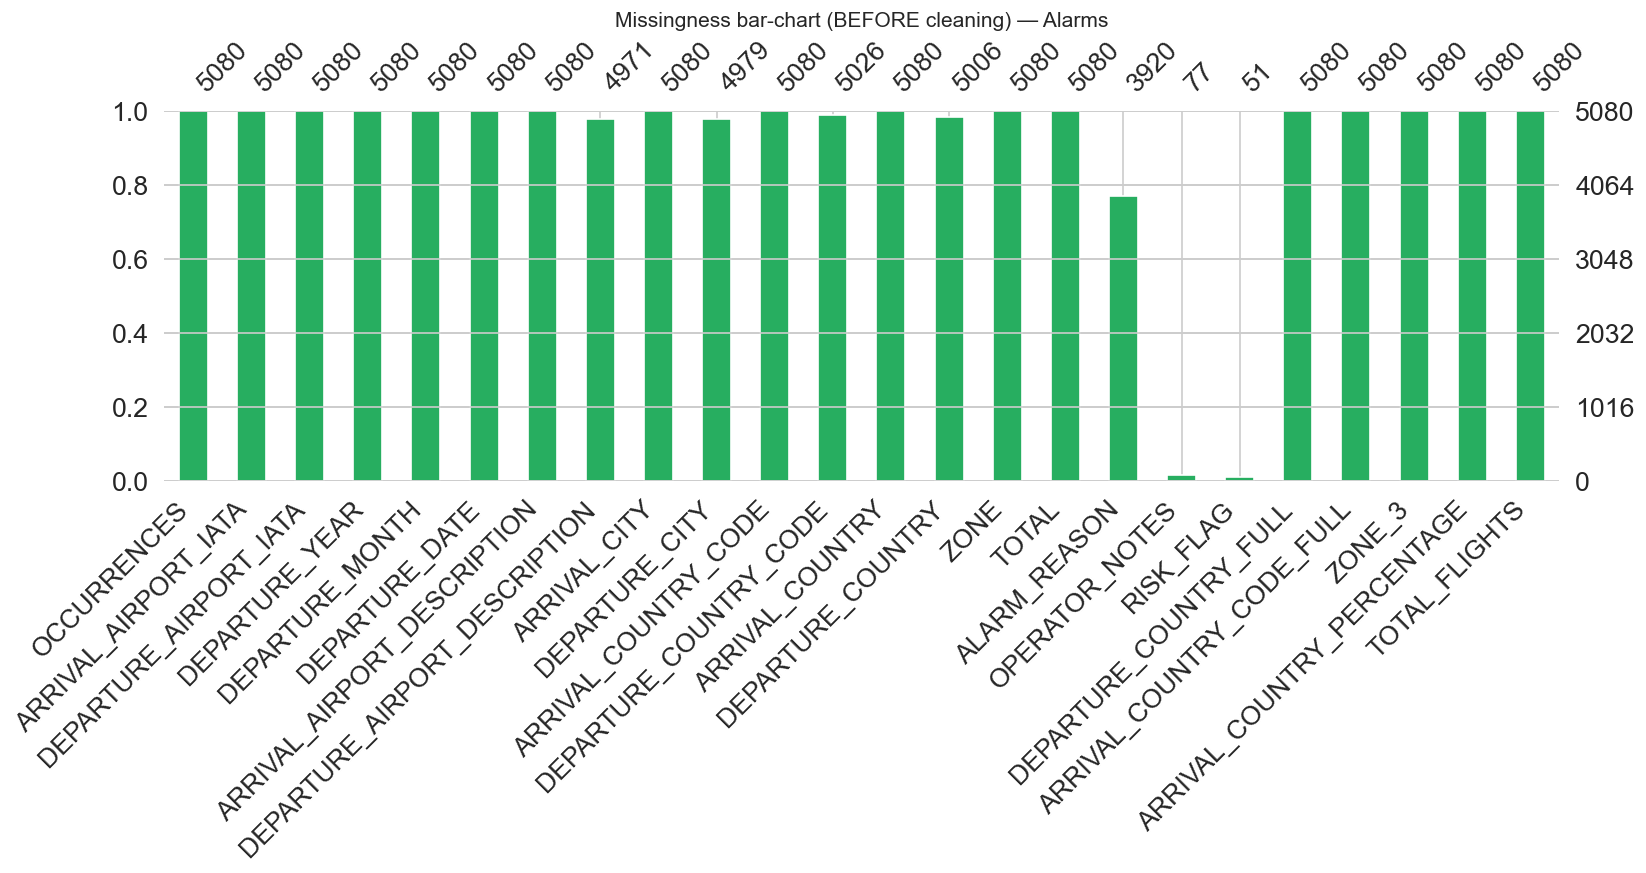

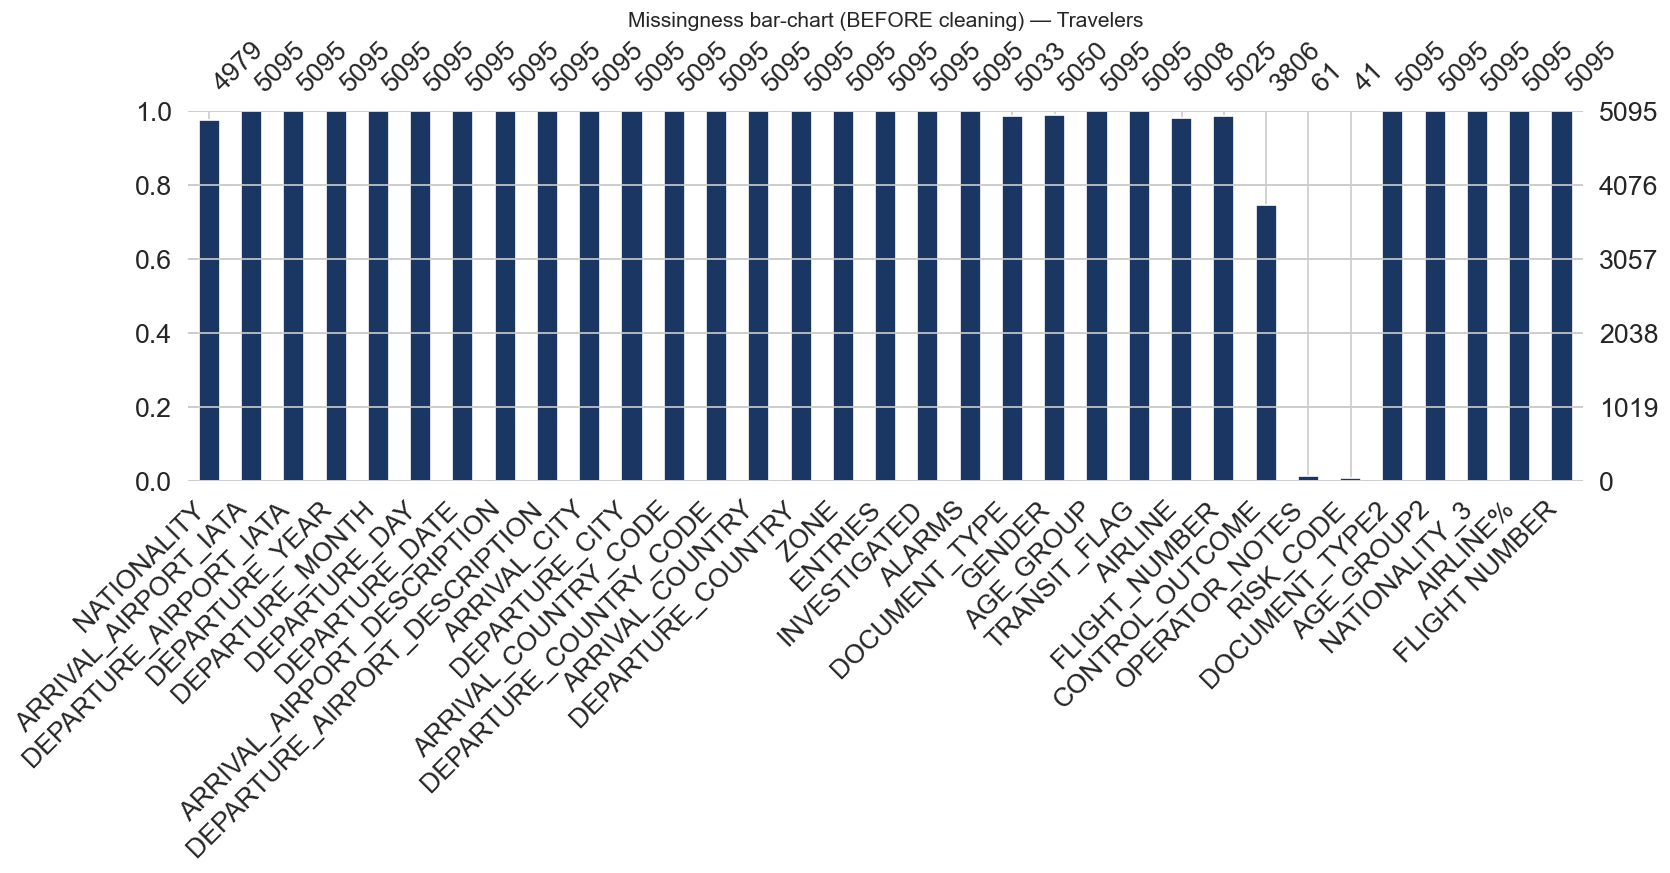

In [531]:
msno.bar(df_alarms, figsize=(15, 4), color=GREEN)
plt.title("Missingness bar-chart (BEFORE cleaning) — Alarms")
plt.show()

msno.bar(df_travelers, figsize=(15, 4), color="#1A3764")
plt.title("Missingness bar-chart (BEFORE cleaning) — Travelers")
plt.show()

raw_missing_alarms    = df_alarms.isnull().sum().copy()
raw_missing_travelers = df_travelers.isnull().sum().copy()
raw_shape_alarms      = df_alarms.shape
raw_shape_travelers   = df_travelers.shape

### 2.2 Categorical-cardinality inspection

We split categorical columns into two buckets: *low-cardinality* (≤ 400 unique values, amenable to visual inspection and rule-based cleanup) and *high-cardinality* (> 400, which will require grouping or encoding). We plot only the first group so the chart stays readable, and print the high-cardinality columns as an early warning. Cardinality > 15 is also flagged in coral as a soft threshold for downstream one-hot encoding.

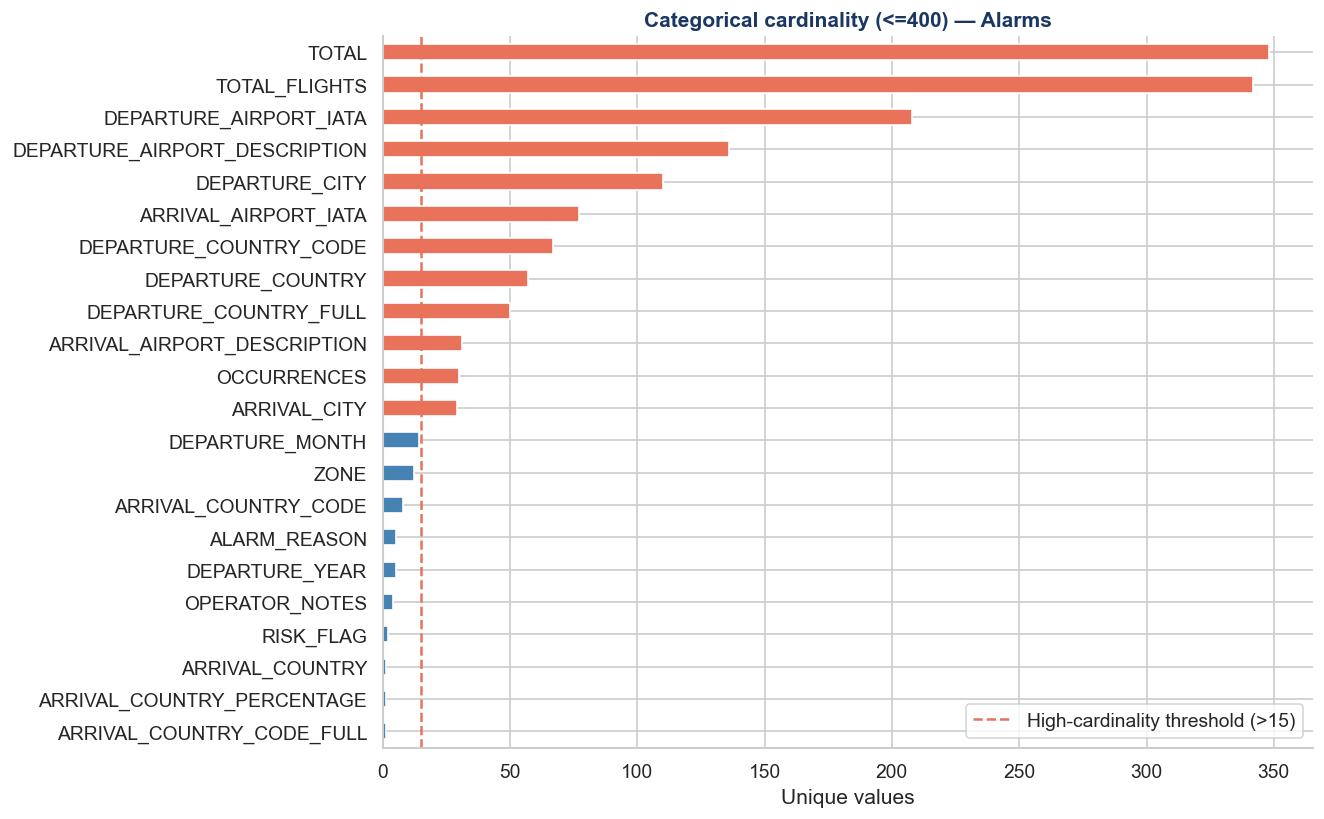

HIGH-CARDINALITY features (excluded from chart):
    'DEPARTURE_DATE': 3810 unique values — needs grouping/target encoding

  Reviewing unique values (Alarms):
  'ARRIVAL_COUNTRY_CODE_FULL' (1 values): ['ITA']

  'ARRIVAL_COUNTRY_PERCENTAGE' (1 values): ['Italia']

  'ARRIVAL_COUNTRY' (1 values): ['Italia']

  'RISK_FLAG' (2 values): ['ALTO', 'MEDIO']

  'OPERATOR_NOTES' (4 values): ['Alert manuale', 'Doppio controllo', 'Passeggero noto', 'Verifica richiesta']

  'DEPARTURE_YEAR' (5 values): ['2023', '2024', '2024.', '24', 'anno 2024']

  'ALARM_REASON' (5 values): ['INTERPOL', 'Manuale', 'NSIS', 'SDI', 'TSC']

  'ARRIVAL_COUNTRY_CODE' (8 values): ['DEU', 'ESP', 'FRA', 'GB', 'GBR', 'IT', 'ITA', 'TUR']

  'ZONE' (12 values): ['-1', '1', '10', '2', '4', '5', '6', '7', '8', '9', '99', '??']

  'DEPARTURE_MONTH' (14 values): ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', 'FEB', 'GEN']

  'ARRIVAL_CITY' (29 values): ['Ancona', 'Bari', 'Bergamo', 'Bologna', 'Bolzano

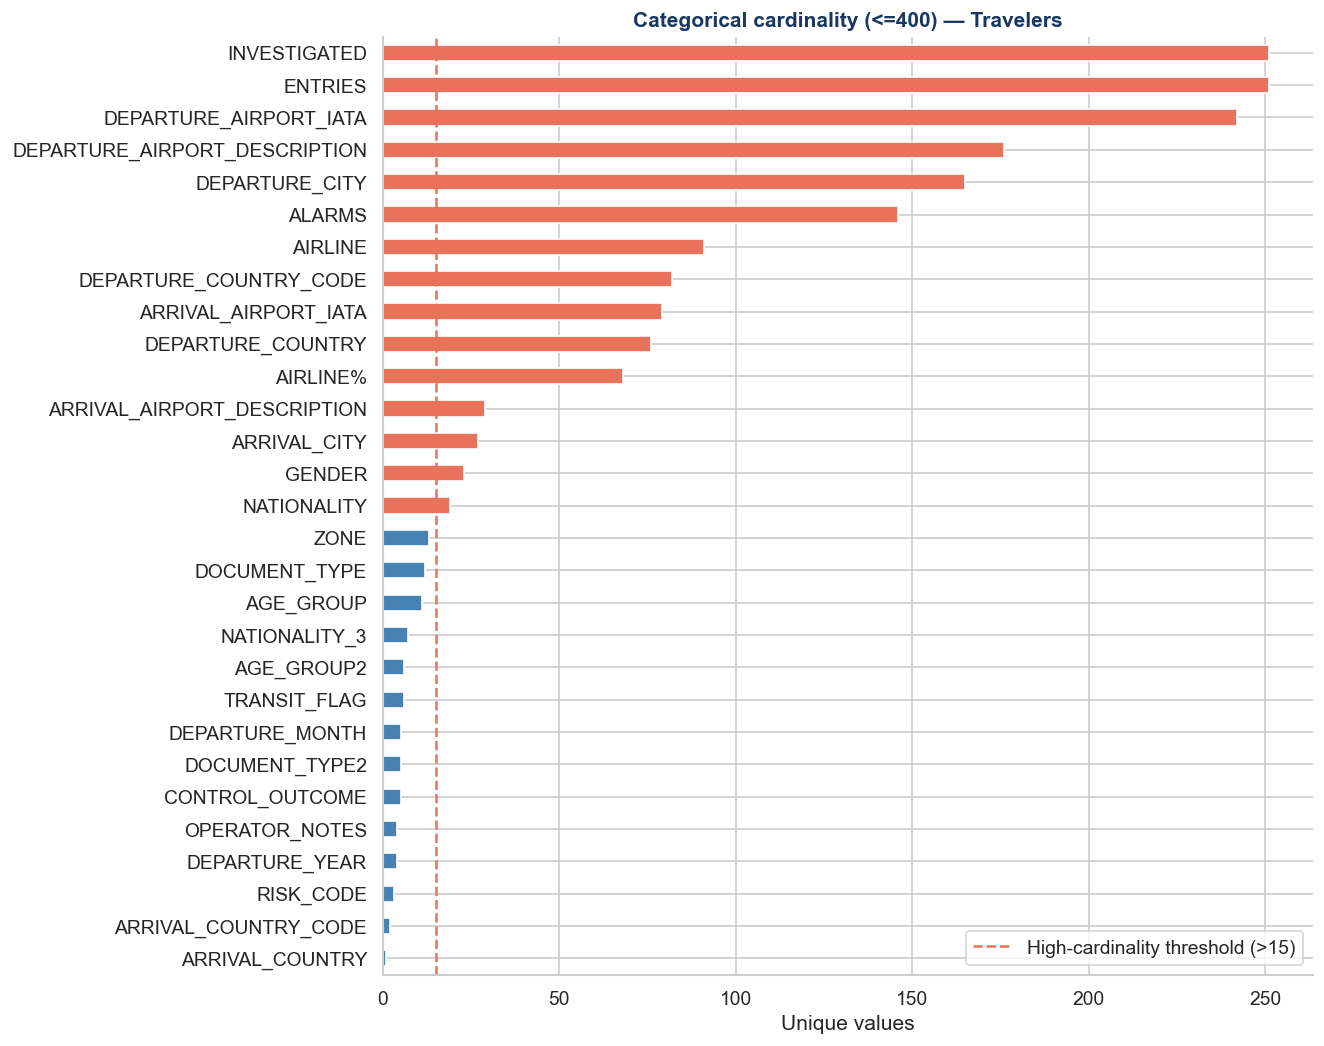

HIGH-CARDINALITY features (excluded from chart):
    'FLIGHT_NUMBER': 701 unique values — needs grouping/target encoding
    'FLIGHT NUMBER': 706 unique values — needs grouping/target encoding
    'DEPARTURE_DATE': 3977 unique values — needs grouping/target encoding

  Reviewing unique values (Travelers):
  'ARRIVAL_COUNTRY' (1 values): ['Italia']

  'ARRIVAL_COUNTRY_CODE' (2 values): ['IT', 'ITA']

  'RISK_CODE' (3 values): ['R1', 'R2', 'R3']

  'DEPARTURE_YEAR' (4 values): ['2023', '2024', '24', 'anno 2024']

  'OPERATOR_NOTES' (4 values): ['Alert manuale', 'Passeggero noto', 'Segnalazione esterna', 'Verifica richiesta']

  'CONTROL_OUTCOME' (5 values): ['FERMATO', 'IN ATTESA', 'OK', 'RESPINTO', 'SEGNALATO']

  'DOCUMENT_TYPE2' (5 values): ["Carta d'identità", 'N.D.', 'Passaporto', 'Permesso di soggiorno', 'Visto']

  'DEPARTURE_MONTH' (5 values): ['01', '02', '12', 'FEB', 'GEN']

  'TRANSIT_FLAG' (6 values): ['Multitratta', 'N/C', 'Singola Tratta', 'TRANSITO', 'Tripla Tratta', 'sing

In [532]:
def inspect_categorical(df, dataset_name):
    """Separate low- and high-cardinality categoricals, plot the former, list the latter."""
    cat_cols = df.select_dtypes(include=["object"]).columns
    if len(cat_cols) == 0:
        print(f"  No categorical columns in {dataset_name}.")
        return

    card = df[cat_cols].nunique().sort_values(ascending=True)
    card_low, card_high = card[card <= 400], card[card > 400]

    if not card_low.empty:
        plt.figure(figsize=(10, max(4, len(card_low) * 0.35)))
        colors = [CORAL if v > 15 else STEEL for v in card_low]
        card_low.plot(kind="barh", color=colors, edgecolor="white")
        plt.axvline(15, color=CORAL, ls="--", lw=1.5,
                    label="High-cardinality threshold (>15)")
        plt.title(f"Categorical cardinality (<=400) — {dataset_name}",
                  fontweight="bold", color=NAVY)
        plt.xlabel("Unique values"); plt.legend(); sns.despine()
        plt.show()

    if not card_high.empty:
        print("HIGH-CARDINALITY features (excluded from chart):")
        for col, val in card_high.items():
            print(f"    '{col}': {val} unique values — needs grouping/target encoding")
        print()

    print(f"  Reviewing unique values ({dataset_name}):")
    for col in card_low.index:
        uv = sorted(df[col].dropna().astype(str).unique())
        print(f"  '{col}' ({len(uv)} values): {uv}\n")

inspect_categorical(df_alarms,    "Alarms")
inspect_categorical(df_travelers, "Travelers")

### 2.3 Travelers cleaning and standardisation

In [533]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "unk", "zz", "none", "xx", "???", " ", "ND", "UNK", "XX", "ZZ", "EU"}

# Departure Colummns analysis
def normalize_departure(df):
    df = df.copy()
    df['DEPARTURE_AIRPORT_IATA'] = (
        df['DEPARTURE_AIRPORT_IATA'].astype(str).str.strip().str.upper().replace({'NAN': np.nan})
    )
    df['DEPARTURE_CITY'] = df['DEPARTURE_AIRPORT_IATA'].map(
        lambda x: iata_mapping[x][0] if x in iata_mapping else np.nan
    )
    df['DEPARTURE_AIRPORT_DESCRIPTION'] = df['DEPARTURE_AIRPORT_IATA'].map(
        lambda x: iata_mapping[x][1] if x in iata_mapping else np.nan
    )
    df['DEPARTURE_COUNTRY'] = df['DEPARTURE_COUNTRY'].astype(str).str.strip()
    df['DEPARTURE_COUNTRY_CODE'] = df['DEPARTURE_COUNTRY'].map(it_to_alpha3)
    return df
df = normalize_departure(df_travelers)
print('Departure columns normalized and enriched with IATA mapping:')
print('country unique         :', df['DEPARTURE_COUNTRY'].nunique())         
print('country code unique    :', df['DEPARTURE_COUNTRY_CODE'].nunique())     
print('iata unique            :', df['DEPARTURE_AIRPORT_IATA'].nunique())
print('airport desc unique    :', df['DEPARTURE_AIRPORT_DESCRIPTION'].nunique())
print('city unique            :', df['DEPARTURE_CITY'].nunique())

miss_iata = (df.loc[df['DEPARTURE_CITY'].isna() & df['DEPARTURE_AIRPORT_IATA'].notna(),'DEPARTURE_AIRPORT_IATA'].unique())
miss_country = (df.loc[df['DEPARTURE_COUNTRY_CODE'].isna() & df['DEPARTURE_COUNTRY'].notna() & (df['DEPARTURE_COUNTRY'] != 'nan'),'DEPARTURE_COUNTRY'].unique())
print('IATA not mapped       :', miss_iata)
print('Country not mapped    :', miss_country)
print('IATA -> city dist.    :', df.groupby('DEPARTURE_AIRPORT_IATA')['DEPARTURE_CITY'].nunique().max())
print('IATA -> airport dist. :', df.groupby('DEPARTURE_AIRPORT_IATA')['DEPARTURE_AIRPORT_DESCRIPTION'].nunique().max())
print('Country -> code dist. :', df.groupby('DEPARTURE_COUNTRY')['DEPARTURE_COUNTRY_CODE'].nunique().max())

# Arrival columns analysis
def normalize_arrival(df):
    df = df.copy()

    df['ARRIVAL_AIRPORT_IATA'] = (
        df['ARRIVAL_AIRPORT_IATA'].astype(str).str.strip().str.upper().replace({'NAN': np.nan})
    )
    df['ARRIVAL_CITY'] = df['ARRIVAL_AIRPORT_IATA'].map(
        lambda x: iata_mapping[x][0] if x in iata_mapping else np.nan
    )
    df['ARRIVAL_AIRPORT_DESCRIPTION'] = df['ARRIVAL_AIRPORT_IATA'].map(
        lambda x: iata_mapping[x][1] if x in iata_mapping else np.nan
    )
    df['ARRIVAL_COUNTRY']      = 'ITALY'
    df['ARRIVAL_COUNTRY_CODE'] = 'ITA'
    return df
df = normalize_arrival(df_travelers)
print('\nArrival columns normalized and enriched with IATA mapping:')
print('iata unique         :', df['ARRIVAL_AIRPORT_IATA'].nunique())    
print('airport desc unique :', df['ARRIVAL_AIRPORT_DESCRIPTION'].nunique())   
print('city unique         :', df['ARRIVAL_CITY'].nunique())                  

miss_iata = (df.loc[df['ARRIVAL_CITY'].isna() & df['ARRIVAL_AIRPORT_IATA'].notna(), 'ARRIVAL_AIRPORT_IATA'].unique())
print('IATA not mapped     :', miss_iata)
print('IATA -> #city dist. :', df.groupby('ARRIVAL_AIRPORT_IATA')['ARRIVAL_CITY'].nunique().max())
print('IATA -> #airport d. :', df.groupby('ARRIVAL_AIRPORT_IATA')['ARRIVAL_AIRPORT_DESCRIPTION'].nunique().max())

# Fix the Zone column by putting -1 99 and ?? to NaN, and converting to numeric. Then combine with ZONE_3 to fill any remaining missing values, before dropping ZONE_3.
if "ZONE" in df_travelers.columns:
    df_travelers["ZONE"] = df_travelers["ZONE"].replace(["-1", "99", "??"], np.nan)
    df_travelers["ZONE"] = pd.to_numeric(df_travelers["ZONE"], errors="coerce")
    df_travelers.loc[(df_travelers["ZONE"] < 0) | (df_travelers["ZONE"] > 10), "ZONE"] = np.nan
    df_travelers["ZONE"] = df_travelers["ZONE"].astype("Int64")
    df_travelers.drop(columns=["ZONE_3"], inplace=True, errors="ignore")
if "ZONE" in df_travelers.columns:
    print(f"\nZONE distribution after cleaning:")
    print(df_travelers["ZONE"].value_counts(dropna=False).to_string())

# Gender analysis: remapping values
if "GENDER" in df_travelers.columns:
    gender_map = {
    "MASCHIO": "M", "MALE": "M", "1": "M", # Man
    "FEMMINA": "F", "FEMALE": "F", "2": "F",  # female
    " ": "N.D.", "-": "N.D.", "//": "N.D.", "X": "N.D.", "N/B": "N.D.", "ND": "N.D.", "UNKNOWN": "N.D.", "UNKN": "N.D.", "?": "N.D."  # Not Declared / Unknown
}
    df_travelers["GENDER"] = df_travelers["GENDER"].str.upper().replace(gender_map).fillna("N.D.")
    print(f"\nGENDER distribution after remapping:")
    print(df_travelers["GENDER"].value_counts(dropna=False).to_string())

# We Standardize Operator Notes, uppercasing and stripping whitespace, then fillna with placeholder and print unique values to check for consistency.
if "OPERATOR_NOTES" in df_travelers.columns:
    df_travelers["OPERATOR_NOTES"] = df_travelers["OPERATOR_NOTES"].str.upper().str.strip()
    df_travelers["OPERATOR_NOTES"] = df_travelers["OPERATOR_NOTES"].replace(np.nan, "NO_NOTES")
    print(f"\nOPERATOR_NOTES unique values after cleaning:")
    print(df_travelers["OPERATOR_NOTES"].value_counts(dropna=False).to_string())

# Transit Flag analysis: we replace null values with "Unknown" and print the distribution to check for consistency.
if "TRANSIT_FLAG" in df_travelers.columns:
    transit_map = {"SINGOLA TRATTA": "1", "MULTITRATTA": "2", "TRIPLA TRATTA": "3", "TRANSITO": "STOPOVER"}
    df_travelers["TRANSIT_FLAG"] = df_travelers["TRANSIT_FLAG"].str.upper().replace(transit_map).replace("N/C", np.nan)
    print(f"\nTRANSIT_FLAG distribution after filling nulls with 'Unknown': {df_travelers['TRANSIT_FLAG'].value_counts(dropna=False).to_string()}")

# Risk code analysis
if "RISK_CODE" in df_travelers.columns:
    print(f"\nRISK_CODE distribution: {df_travelers['RISK_CODE'].value_counts(dropna=False).to_string()}")

# Control outcome analysis
if "CONTROL_OUTCOME" in df_travelers.columns:
    print(f"\nCONTROL_OUTCOME distribution: {df_travelers['CONTROL_OUTCOME'].value_counts(dropna=False).to_string()}")

# replace null values in nationality with "Unknown"
if "NATIONALITY" in df_travelers.columns:
    df_travelers["NATIONALITY"] = df_travelers["NATIONALITY"].fillna("Unknown")
    df_travelers["NATIONALITY"] = df_travelers["NATIONALITY"].replace(PLACEHOLDER_NULL, "Unknown")
    print(f"\nNATIONALITY distribution after filling nulls with 'Unknown':")
    print(df_travelers["NATIONALITY"].value_counts(dropna=False).to_string())
# if the values differnet from "Unknown" are the same in nationality and nationality_3, we can can drop nationality_3
if "NATIONALITY" in df_travelers.columns and "NATIONALITY_3" in df_travelers.columns:
    if set(df_travelers.loc[df_travelers["NATIONALITY"] != "Unknown", "NATIONALITY"].unique()) == set(df_travelers.loc[df_travelers["NATIONALITY"] != "Unknown", "NATIONALITY_3"].unique()):
        df_travelers.drop(columns=["NATIONALITY_3"], inplace=True, errors="ignore")
        print("\nDropped 'NATIONALITY_3' since it is redundant with 'NATIONALITY' after filling nulls.")

# We drop Departure Year and Month since they are redundant with Departure Date, which is more complete and can be used to extract the year and month if needed.
if "DEPARTURE_DATE" in df_travelers.columns:
    df_travelers.drop(columns=["DEPARTURE_YEAR", "DEPARTURE_MONTH"], inplace=True, errors="ignore")
    print("\nDropped 'DEPARTURE_YEAR' and 'DEPARTURE_MONTH' since they are redundant with 'DEPARTURE_DATE'.")

# Age_group and Age_group2 analysis: Since they are related and Age_group2 has a normal distribution without outliers, we can drop Age_group and keep Age_group2 as the main age feature.
if "AGE_GROUP" in df_travelers.columns and "AGE_GROUP2" in df_travelers.columns:
    df_travelers.drop(columns=["AGE_GROUP"], inplace=True, errors="ignore")
    print("\nDropped 'AGE_GROUP' since 'AGE_GROUP2' has a more consistent distribution without outliers.")

# Document type and Document type 2 analysis: since they are related and Document type 2 has a more consistent distribution without outliers, we can drop Document type and keep Document type 2 as the main document type feature.
if "DOCUMENT_TYPE" in df_travelers.columns and "DOCUMENT_TYPE2" in df_travelers.columns:
    df_travelers.drop(columns=["DOCUMENT_TYPE"], inplace=True, errors="ignore")
    print("\nDropped 'DOCUMENT_TYPE' since 'DOCUMENT_TYPE2' has a more consistent distribution without outliers.")

# Airline and Airline% analysis: since they are related and Airline% has a more consistent distribution without outliers, we can drop Airline and keep Airline as the main airline feature.
if "AIRLINE" in df_travelers.columns and "AIRLINE%" in df_travelers.columns:
    df_travelers.drop(columns=["AIRLINE"], inplace=True, errors="ignore")
    print("\nDropped 'AIRLINE' since 'AIRLINE%' has a more consistent distribution without outliers.")

# Flight number and Flight number analysis: # remove the - in the values and spaces in the values, then print the unique values to check for consistency.
# Since they are related and Flight number has a more consistent distribution without outliers, we can drop Flight_number and keep Flight number as the main flight number feature.
if "FLIGHT_NUMBER" in df_travelers.columns and "FLIGHT NUMBER" in df_travelers.columns:
    df_travelers["FLIGHT_NUMBER"] = df_travelers["FLIGHT_NUMBER"].str.replace("-", "").str.replace(" ", "").str.upper()
    df_travelers["FLIGHT NUMBER"] = df_travelers["FLIGHT NUMBER"].str.replace("-", "").str.replace(" ", "").str.upper()
    df_travelers.drop(columns=["FLIGHT_NUMBER"], inplace=True, errors="ignore")
    print("\nDropped 'FLIGHT_NUMBER' since 'FLIGHT NUMBER' has a more consistent distribution without outliers.")

# Finally, we clean the signal columns (Entries, Investigated, Alarms) by removing non-numeric characters, converting to numeric, and filtering out invalid values (negative or >200). 
# We then print the top 5 largest values in each column to check for consistency.
signal_cols = ['ENTRIES', 'INVESTIGATED', 'ALARMS']
before = len(df_travelers)
for col in signal_cols:
    df_travelers[col] = (df_travelers[col].astype(str)
                        .str.replace(r'(?i)pax', '', regex=True)
                        .str.replace(r'\s+', '', regex=True)
    )
    df_travelers[col] = pd.to_numeric(df_travelers[col], errors='coerce')
mask = (
    df_travelers['ENTRIES'].between(0, 200) &
    df_travelers['INVESTIGATED'].between(0, 200) &
    df_travelers['ALARMS'].between(0, 200)
)
df_travelers = df_travelers[mask].copy()
print(f"\nDropped {before - len(df_travelers)} rows (negative, >200, or non-numeric) in ENTRIES, INVESTIGATED, or ALARMS columns.")

for col in signal_cols:
    df_travelers[col] = df_travelers[col].astype(int)
    print(f"\nTop 5 values in '{col}':")
    print(df_travelers[col].nlargest(5).to_string())

# Save cleaned datasets
df_travelers.to_csv("io/TRAVELERS_CLEANED.csv", index=False)
print(f"\nCleaned travelers dataset {df_travelers.shape[0]} rows x {df_travelers.shape[1]} columns saved to 'io/TRAVELERS_CLEANED.csv'.")

Departure columns normalized and enriched with IATA mapping:
country unique         : 76
country code unique    : 76
iata unique            : 177
airport desc unique    : 176
city unique            : 165
IATA not mapped       : []
Country not mapped    : []
IATA -> city dist.    : 1
IATA -> airport dist. : 1
Country -> code dist. : 1

Arrival columns normalized and enriched with IATA mapping:
iata unique         : 29
airport desc unique : 29
city unique         : 27
IATA not mapped     : []
IATA -> #city dist. : 1
IATA -> #airport d. : 1

ZONE distribution after cleaning:
ZONE
2       1774
5       1106
8        878
4        564
1        252
9        220
7        184
6        107
<NA>       5
0          4
10         1

GENDER distribution after remapping:
GENDER
F       2248
M       2210
N.D.     637

OPERATOR_NOTES unique values after cleaning:
OPERATOR_NOTES
NO_NOTES                5034
VERIFICA RICHIESTA        18
ALERT MANUALE             16
SEGNALAZIONE ESTERNA      16
PASSEGGERO N

### 2.4 ALARMS cleaning and standardisation

In [534]:
# Dropping columns from alarms that are redundant with travelers or have too many missing values, and printing the distribution of the remaining columns to check for consistency.
df_alarms.drop(columns=["DEPARTURE_MONTH", "DEPARTURE_YEAR", "ARRIVAL_COUNTRY_CODE", "ARRIVAL_COUNTRY_CODE_PERCENTAGE"], inplace=True, errors="ignore")

# Cleaning function
PLACEHOLDER_NULL = {'n.d.', '?', '', '//', '-', 'unknown', 'nd', 'n/a', 'null', 'none'}
def clean_placeholders(s):
    s = s.astype(str).str.strip()
    return s.where(~s.str.lower().isin(PLACEHOLDER_NULL), np.nan)

# Occurces map: we lowercase, strip, and map to the standardized categories, then print the distribution to check for consistency.
df_alarms['OCCURRENCES'] = df_alarms['OCCURRENCES'].str.lower().str.strip().map(occurrences_map)
print("OCCURRENCES distribution:")
print(df_alarms["OCCURRENCES"].value_counts(dropna=False).to_string())

# Zone column analysis: we replace -1, 99, and ?? with NaN, convert to numeric, and filter out invalid values (negative or >10). 
# We then combine with ZONE_3 to fill any remaining missing values, before dropping ZONE_3. Finally, we print the distribution to check for consistency.
if "ZONE" in df_alarms.columns:
    df_alarms["ZONE"] = pd.to_numeric(
        df_alarms["ZONE"].replace(["-1", "99", "??"], np.nan), errors="coerce"
    )
    df_alarms.loc[(df_alarms["ZONE"] < 0) | (df_alarms["ZONE"] > 10), "ZONE"] = np.nan
    df_alarms["ZONE"] = (df_alarms["ZONE"].astype("Int64").combine_first(df_alarms["ZONE_3"]))
    df_alarms.drop(columns=["ZONE_3"], inplace=True, errors="ignore")
    print(f"\nZONE distribution after cleaning:\n{df_alarms['ZONE'].value_counts(dropna=False).to_string()}")

# ALARM_REASON / OPERATOR_NOTES: uppercase + placeholder fill
text_fill = {"ALARM_REASON": "NO REASON PROVIDED", "OPERATOR_NOTES": "NO MANUAL NOTES"}
for col, placeholder in text_fill.items():
    if col in df_alarms.columns:
        df_alarms[col] = (df_alarms[col].astype(str).str.strip().str.upper()
                                        .replace({'NAN': np.nan})
                                        .fillna(placeholder))

# RISK_FLAG: translate IT->EN, fill NaN with LOW RISK
if "RISK_FLAG" in df_alarms.columns:
    df_alarms["RISK_FLAG"] = (df_alarms["RISK_FLAG"]
                              .replace({"ALTO": "HIGH RISK", "MEDIO": "MEDIUM RISK"})
                              .fillna("LOW RISK"))
    print(f"\nRISK_FLAG distribution:\n{df_alarms['RISK_FLAG'].value_counts(dropna=False).to_string()}")

# DEPARTURE: IATA -> city + airport, country -> alpha-3 
iata_to_city    = {k: v[0] for k, v in iata_mapping.items()}
iata_to_airport = {k: v[1] for k, v in iata_mapping.items()}

iata_dep = df_alarms['DEPARTURE_AIRPORT_IATA'].astype(str).str.upper().str.strip()
df_alarms['DEPARTURE_AIRPORT_IATA']        = iata_dep
df_alarms['DEPARTURE_CITY']                = iata_dep.map(iata_to_city)
df_alarms['DEPARTURE_AIRPORT_DESCRIPTION'] = iata_dep.map(iata_to_airport)

# Combine the 2 country columns: prefer DEPARTURE_COUNTRY_FULL (already standardised),
# fallback on DEPARTURE_COUNTRY for missing values
country = (clean_placeholders(df_alarms['DEPARTURE_COUNTRY_FULL'])
           .combine_first(clean_placeholders(df_alarms['DEPARTURE_COUNTRY'])))
df_alarms['DEPARTURE_COUNTRY']      = country
df_alarms['DEPARTURE_COUNTRY_CODE'] = country.map(it_to_alpha3)
df_alarms.drop(columns=['DEPARTURE_COUNTRY_FULL'], inplace=True, errors='ignore')

print('\n--- DEPARTURE ---')
print(f"  IATA unique         : {df_alarms['DEPARTURE_AIRPORT_IATA'].nunique()}")
print(f"  airport desc unique : {df_alarms['DEPARTURE_AIRPORT_DESCRIPTION'].nunique()}")
print(f"  city unique         : {df_alarms['DEPARTURE_CITY'].nunique()}")
print(f"  country unique      : {df_alarms['DEPARTURE_COUNTRY'].nunique()}")
print(f"  country code unique : {df_alarms['DEPARTURE_COUNTRY_CODE'].nunique()}")
print(f"  city -> airport null : {df_alarms['DEPARTURE_CITY'].isna().sum()} -> "
      f"{df_alarms['DEPARTURE_AIRPORT_DESCRIPTION'].isna().sum()}")
print(f"  country code null   : {df_alarms['DEPARTURE_COUNTRY_CODE'].isna().sum()}")

# ARRIVAL: IATA -> city + airport, country = Italy
iata_arr = df_alarms['ARRIVAL_AIRPORT_IATA'].astype(str).str.upper().str.strip()
df_alarms['ARRIVAL_AIRPORT_IATA']        = iata_arr
df_alarms['ARRIVAL_CITY']                = iata_arr.map(iata_to_city)
df_alarms['ARRIVAL_AIRPORT_DESCRIPTION'] = iata_arr.map(iata_to_airport)
df_alarms['ARRIVAL_COUNTRY']             = 'Italia'
df_alarms['ARRIVAL_COUNTRY_CODE']        = 'ITA'

print('\n--- ARRIVAL ---')
print(f"  IATA unique         : {df_alarms['ARRIVAL_AIRPORT_IATA'].nunique()}")
print(f"  airport desc unique : {df_alarms['ARRIVAL_AIRPORT_DESCRIPTION'].nunique()}")
print(f"  city unique         : {df_alarms['ARRIVAL_CITY'].nunique()}")
print(f"  city -> airport null : {df_alarms['ARRIVAL_CITY'].isna().sum()} -> "
      f"{df_alarms['ARRIVAL_AIRPORT_DESCRIPTION'].isna().sum()}")

# TOTAL_FLIGHTS: keep clean column, drop noisy TOTAL
def clean_count(series, max_valid=1000):
    s = (series.astype(str).str.strip()
                .str.replace(r'\s*voli\s*$', '', regex=True)
                .str.lstrip('~'))
    s = pd.to_numeric(s, errors='coerce')
    return s.where((s >= 0) & (s <= max_valid)).fillna(0).round().astype(int)

df_alarms['TOTAL_FLIGHTS'] = clean_count(df_alarms['TOTAL_FLIGHTS'])
df_alarms.drop(columns=['TOTAL'], inplace=True, errors='ignore')
print(f"\nTOTAL_FLIGHTS:\n{df_alarms['TOTAL_FLIGHTS'].describe().to_string()}")

# Save cleaned dataset
df_alarms.to_csv("io/ALARMS_CLEANED.csv", index=False)
print(f"\nCleaned alarms dataset {df_alarms.shape[0]} rows x {df_alarms.shape[1]} cols saved to 'io/ALARMS_CLEANED.csv'.")

OCCURRENCES distribution:
OCCURRENCES
entries                            626
available_inbound_flights          588
viewed_not_investigated_flights    572
generated_alerts                   547
investigated_flights               543
investigated_entries               528
flights_with_alerts                507
entries_with_alerts                468
negative_outcome                   296
closed_alerts                      259
relevant_alerts                    112
other                               16
missing_update                       8
open_alerts                          7
NaN                                  3

ZONE distribution after cleaning:
ZONE
2     1841
5     1474
8      580
4      568
6      213
1      180
7      144
9       79
10       1

RISK_FLAG distribution:
RISK_FLAG
LOW RISK       5029
HIGH RISK        27
MEDIUM RISK      24

--- DEPARTURE ---
  IATA unique         : 112
  airport desc unique : 111
  city unique         : 103
  country unique      : 50
  country cod

### 2.5 Date parsing & temporal alignment

The two datasets use *different* date conventions, and the Alarms file in particular mixes at least six formats (`dd/mm/yyyy HH:MM:SS`, `yyyy/mm/dd`, `dd.mm.yyyy`, `MMM dd yyyy` with Italian month abbreviations, `dd-mm-yy`, …). We:

1. print the format distribution *before* cleaning by replacing digits with `N` and letters with `A` (a "pattern fingerprint" technique);
2. rewrite each known pattern to ISO 8601 via regex;
3. parse with `pd.to_datetime(..., errors='coerce')`;
4. print the fingerprint distribution *after* cleaning to verify every row now conforms.

In [535]:
def extract_pattern(val):
    s = re.sub(r"\d", "N", str(val))
    return re.sub(r"[a-zA-Z]", "A", s)

def parse_dates(s, name=""):
    raw = (s.astype(str).str.strip()
            .str.replace(r"(\d{4}-\d{2}-\d{2})(\d{2}:\d{2}:\d{2})",
                         r"\1 \2", regex=True))
    out = pd.to_datetime(raw, format='mixed', dayfirst=True, errors='coerce')
    out = out.fillna(pd.to_datetime(raw, errors='coerce'))
    print(f"  {name}: parse failures (will be dropped) = {out.isna().sum()}")
    return out

# Inspect formats BEFORE
print("Date-format patterns BEFORE cleaning:")
for name, df in [("Alarms", df_alarms), ("Travelers", df_travelers)]:
    counts = df["DEPARTURE_DATE"].dropna().astype(str).map(extract_pattern).value_counts()
    print(f"  {name}:\n    " + counts.to_string().replace("\n", "\n    "))

# Parse
print("\nParsing:")
df_alarms["DEPARTURE_DATE"]    = parse_dates(df_alarms["DEPARTURE_DATE"],    "Alarms")
df_travelers["DEPARTURE_DATE"] = parse_dates(df_travelers["DEPARTURE_DATE"], "Travelers")

# Drop rows that couldn't be parsed
before = len(df_alarms), len(df_travelers)
df_alarms    = df_alarms.dropna(subset=["DEPARTURE_DATE"]).reset_index(drop=True)
df_travelers = df_travelers.dropna(subset=["DEPARTURE_DATE"]).reset_index(drop=True)
print(f"\nRows dropped: Alarms {before[0]-len(df_alarms)} | Travelers {before[1]-len(df_travelers)}")

# Inspect formats AFTER
print("\nDate-format patterns AFTER cleaning:")
for name, df in [("Alarms", df_alarms), ("Travelers", df_travelers)]:
    counts = df["DEPARTURE_DATE"].dropna().astype(str).map(extract_pattern).value_counts()
    print(f"  {name}:\n    " + counts.to_string().replace("\n", "\n    "))

Date-format patterns BEFORE cleaning:
  Alarms:
    DEPARTURE_DATE
    AAAA-AA-AA AA:AA:AA    4675
    AAAA/AA/AA               76
    AA-AA-AA                 76
    AAA AA AAAA              68
    AA.AA.AAAA               62
    AAAA-AA-AAAAA:AA:AA      62
    AA/AA/AAAA AA:AA:AA      61
  Travelers:
    DEPARTURE_DATE
    AAAA-AA-AA AA:AA:AA    4485
    AAA AA AAAA              78
    AAAA-AA-AAAAA:AA:AA      65
    AA-AA-AA                 65
    AAAA/AA/AA               65
    AA/AA/AAAA AA:AA:AA      65
    AA.AA.AAAA               54

Parsing:
  Alarms: parse failures (will be dropped) = 32
  Travelers: parse failures (will be dropped) = 37

Rows dropped: Alarms 32 | Travelers 37

Date-format patterns AFTER cleaning:
  Alarms:
    DEPARTURE_DATE
    AAAA-AA-AA AA:AA:AA    5048
  Travelers:
    DEPARTURE_DATE
    AAAA-AA-AA AA:AA:AA    4840


### 2.6 Post-cleaning missing-value audit

A side-by-side table compares *per column* the number of missing values before and after section 2.3 – section 2.7. We only show rows where the count actually changed — the rest is untouched. The follow-up `missingno` bar-charts in green confirm visually that the key fields are now dense.


ALARMS  (shape: (5080, 24) -> (5048, 19))


,Missing BEFORE,Missing AFTER
Column,,
ALARM_REASON,1160,0
ARRIVAL_AIRPORT_DESCRIPTION,0,0
ARRIVAL_AIRPORT_IATA,0,0
ARRIVAL_CITY,0,0
ARRIVAL_COUNTRY,0,0
ARRIVAL_COUNTRY_CODE,0,0
ARRIVAL_COUNTRY_CODE_FULL,0,0
ARRIVAL_COUNTRY_PERCENTAGE,0,0
DEPARTURE_AIRPORT_DESCRIPTION,109,0



TRAVELERS  (shape: (5095, 33) -> (4840, 26))


,Missing BEFORE,Missing AFTER
Column,,
AGE_GROUP,0,dropped
AGE_GROUP2,0,0
AIRLINE,87,dropped
AIRLINE%,0,0
ALARMS,0,0
ARRIVAL_AIRPORT_DESCRIPTION,0,0
ARRIVAL_AIRPORT_IATA,0,0
ARRIVAL_CITY,0,0
ARRIVAL_COUNTRY,0,0


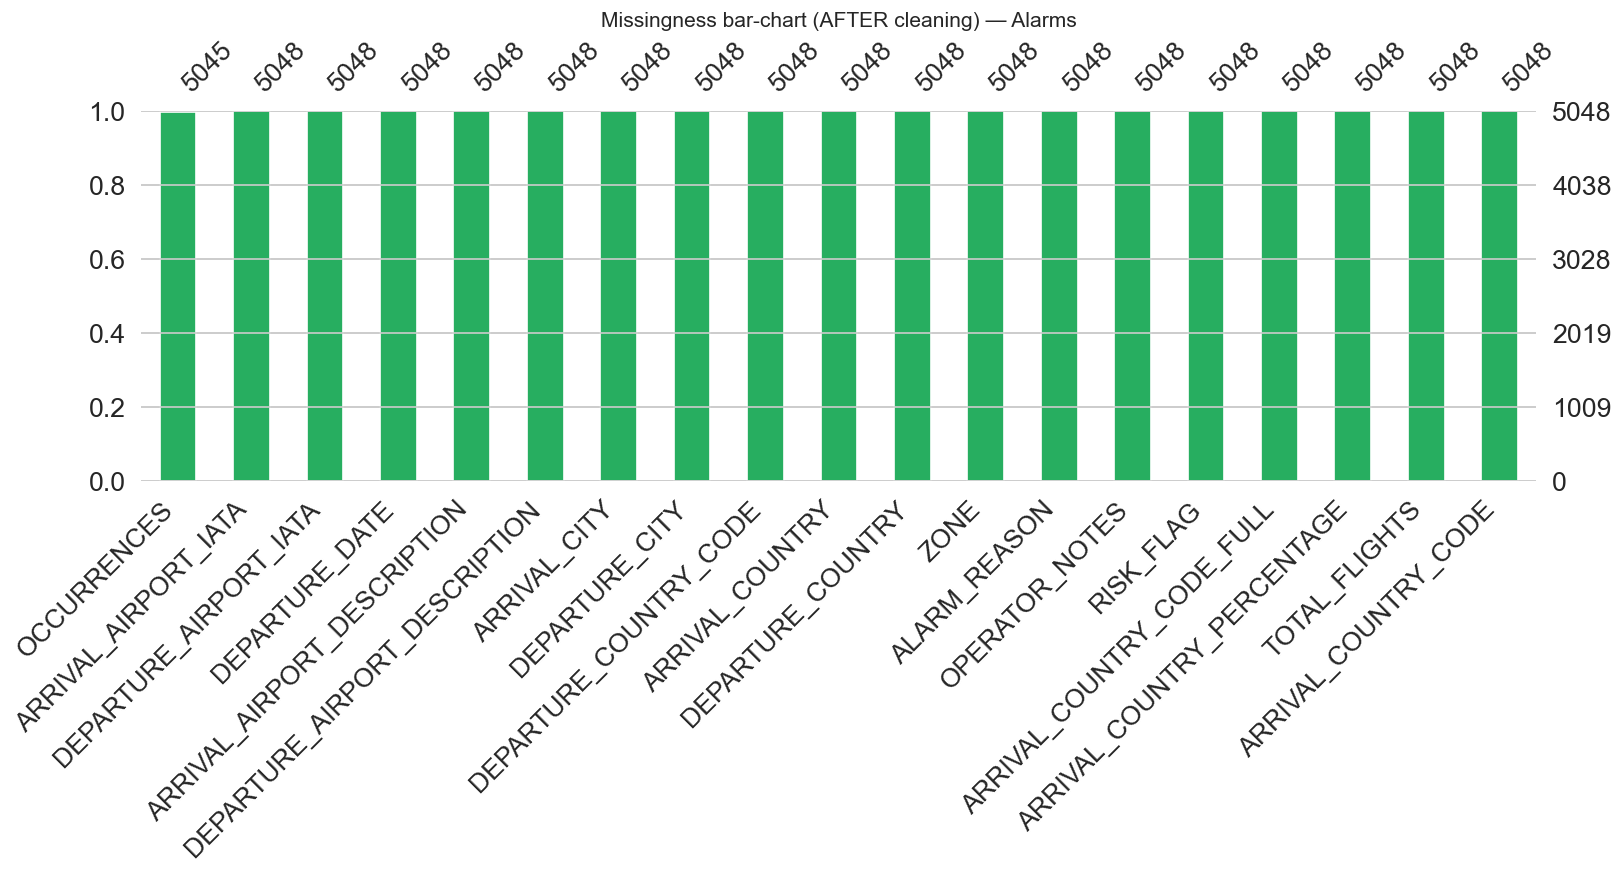

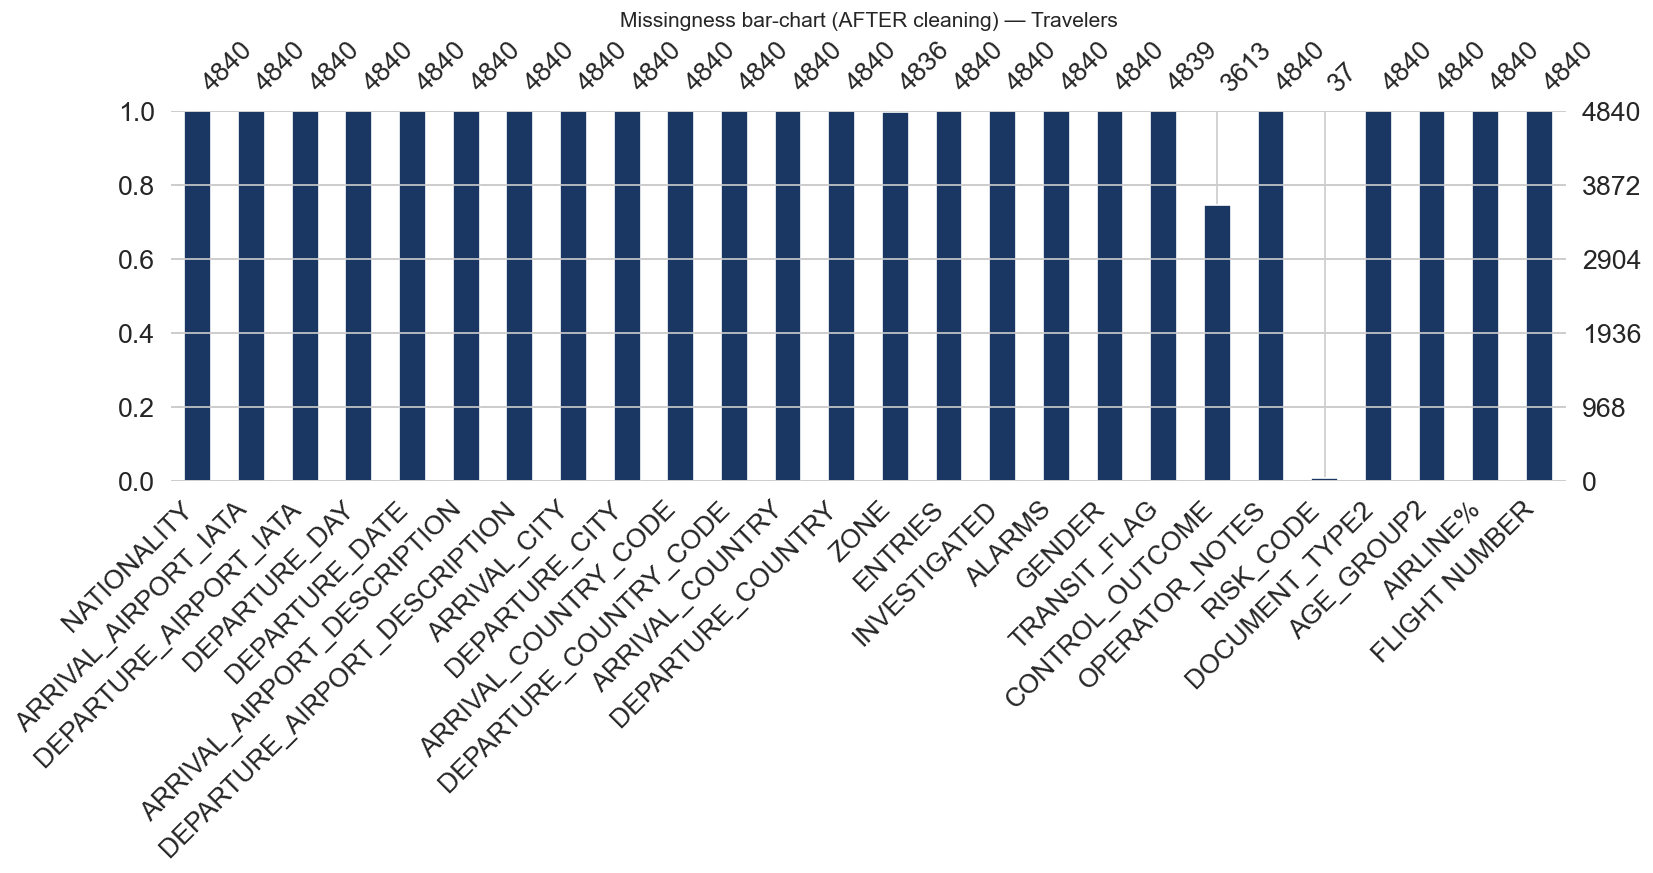

In [536]:
def missing_comparison(df_now, raw_missing, dataset_name, raw_shape):
    """Compare per-column missing-value counts before and after the cleaning pipeline."""
    now = df_now.isnull().sum()
    col_map = {c.upper(): c for c in df_now.columns}
    raw_missing = raw_missing.copy()
    raw_missing.index = [col_map.get(c.upper(), c) for c in raw_missing.index]
    all_cols = sorted(set(raw_missing.index) | set(now.index))
    rows = [{"Column": c,
             "Missing BEFORE": raw_missing.get(c, "—"),
             "Missing AFTER":  now.get(c, "dropped")} for c in all_cols]
    report = pd.DataFrame(rows).set_index("Column")
    print(f"\n{dataset_name}  (shape: {raw_shape} -> {df_now.shape})")
    display(report)

missing_comparison(df_alarms,    raw_missing_alarms,    "ALARMS",    raw_shape_alarms)
missing_comparison(df_travelers, raw_missing_travelers, "TRAVELERS", raw_shape_travelers)

msno.bar(df_alarms, figsize=(15, 4), color=GREEN)
plt.title("Missingness bar-chart (AFTER cleaning) — Alarms")
plt.show()

msno.bar(df_travelers, figsize=(15, 4), color="#1A3764")
plt.title("Missingness bar-chart (AFTER cleaning) — Travelers")
plt.show()

### 2.7 Final schema verification

We print the final shape, column list, and dtype counts for both datasets — the schema contract on which the feature-engineering block will depend. The cleaned DataFrames remain in memory (`df_alarms`, `df_travelers`); no disk persistence is required since the notebook runs end-to-end in a single session.


In [537]:
print(f"ALARMS -> {df_alarms.shape[0]:,} rows x {df_alarms.shape[1]} cols")
# order columns for better readability
cols_order = ['DEPARTURE_DATE', 'DEPARTURE_AIRPORT_IATA', 'DEPARTURE_CITY', 'DEPARTURE_AIRPORT_DESCRIPTION', 'DEPARTURE_COUNTRY', 'DEPARTURE_COUNTRY_CODE', 
              'ARRIVAL_AIRPORT_IATA', 'ARRIVAL_CITY', 'ARRIVAL_AIRPORT_DESCRIPTION', 'ARRIVAL_COUNTRY', 'ARRIVAL_COUNTRY_CODE', 'ZONE',
               'OCCURRENCES', 'ALARM_REASON', 'OPERATOR_NOTES', 'RISK_FLAG', 'TOTAL_FLIGHTS']
df_alarms = df_alarms[cols_order + [col for col in df_alarms.columns if col not in cols_order]]
df_alarms.sample(5)

ALARMS -> 5,048 rows x 19 cols


,DEPARTURE_DATE,DEPARTURE_AIRPORT_IATA,DEPARTURE_CITY,DEPARTURE_AIRPORT_DESCRIPTION,DEPARTURE_COUNTRY,DEPARTURE_COUNTRY_CODE,ARRIVAL_AIRPORT_IATA,ARRIVAL_CITY,ARRIVAL_AIRPORT_DESCRIPTION,ARRIVAL_COUNTRY,ARRIVAL_COUNTRY_CODE,ZONE,OCCURRENCES,ALARM_REASON,OPERATOR_NOTES,RISK_FLAG,TOTAL_FLIGHTS,ARRIVAL_COUNTRY_CODE_FULL,ARRIVAL_COUNTRY_PERCENTAGE
4692,2024-02-10 18:30:00,LHR,London,London Heathrow,Regno Unito,GBR,BLQ,Bologna,Guglielmo Marconi,Italia,ITA,8,generated_alerts,TSC,NO MANUAL NOTES,LOW RISK,4,ITA,Italia
4040,2024-01-06 02:20:00,DOH,Doha,Hamad International,Qatar,QAT,MXP,Milano,Malpensa,Italia,ITA,2,closed_alerts,MANUALE,NO MANUAL NOTES,LOW RISK,9,ITA,Italia
3502,2024-02-15 15:30:00,DOH,Doha,Hamad International,Qatar,QAT,MXP,Milano,Malpensa,Italia,ITA,2,available_inbound_flights,MANUALE,NO MANUAL NOTES,LOW RISK,1,ITA,Italia
373,2024-01-13 12:50:00,CAI,Cairo,Cairo International,Egitto,EGY,MXP,Milano,Malpensa,Italia,ITA,2,entries_with_alerts,MANUALE,NO MANUAL NOTES,LOW RISK,29,ITA,Italia
4240,2024-01-14 08:40:00,IST,Istanbul,Istanbul Airport,Turchia,TUR,MXP,Milano,Malpensa,Italia,ITA,2,investigated_entries,NSIS,NO MANUAL NOTES,LOW RISK,174,ITA,Italia


In [538]:
print(f"TRAVELERS -> {df_travelers.shape[0]:,} rows x {df_travelers.shape[1]} cols")
# order columns for better readability
cols_order = ['DEPARTURE_DATE', 'DEPARTURE_AIRPORT_IATA', 'DEPARTURE_CITY', 'DEPARTURE_AIRPORT_DESCRIPTION', 'DEPARTURE_COUNTRY', 'DEPARTURE_COUNTRY_CODE', 
              'ARRIVAL_AIRPORT_IATA', 'ARRIVAL_CITY', 'ARRIVAL_AIRPORT_DESCRIPTION', 'ARRIVAL_COUNTRY', 'ARRIVAL_COUNTRY_CODE', 'ZONE', 
              'GENDER', 'NATIONALITY', 'TRANSIT_FLAG', 'RISK_CODE', 'CONTROL_OUTCOME', 'AGE_GROUP2', 'DOCUMENT_TYPE2', 'AIRLINE%', 'FLIGHT NUMBER', 'OPERATOR_NOTES', 'ENTRIES', 'INVESTIGATED', 'ALARMS']
df_travelers = df_travelers[cols_order + [col for col in df_travelers.columns if col not in cols_order]]
df_travelers.sample(5)

TRAVELERS -> 4,840 rows x 26 cols


,DEPARTURE_DATE,DEPARTURE_AIRPORT_IATA,DEPARTURE_CITY,DEPARTURE_AIRPORT_DESCRIPTION,DEPARTURE_COUNTRY,DEPARTURE_COUNTRY_CODE,ARRIVAL_AIRPORT_IATA,ARRIVAL_CITY,ARRIVAL_AIRPORT_DESCRIPTION,ARRIVAL_COUNTRY,ARRIVAL_COUNTRY_CODE,ZONE,GENDER,NATIONALITY,TRANSIT_FLAG,RISK_CODE,CONTROL_OUTCOME,AGE_GROUP2,DOCUMENT_TYPE2,AIRLINE%,FLIGHT NUMBER,OPERATOR_NOTES,ENTRIES,INVESTIGATED,ALARMS,DEPARTURE_DAY
2912,2024-01-16 15:45:00,TIA,Tirana,Rinas Mother Teresa,Albania,ALB,FCO,Roma,Fiumicino,Italia,ITA,5,M,ALB,1,NaN,FERMATO,0-17,Carta d'identità,ITA Airways,AZ0585,NO_NOTES,31,34,4,16
3386,2024-01-08 13:40:00,JFK,New York,John F Kennedy International,Stati Uniti,USA,VCE,Venezia,Venezia Marco Polo,Italia,ITA,4,M,Unknown,1,NaN,OK,N.D.,Carta d'identità,British Airways,BA0582,NO_NOTES,1,1,0,8
300,2024-02-10 16:20:00,TIA,Tirana,Rinas Mother Teresa,Albania,ALB,TRS,Trieste,Ronchi Dei Legionari,Italia,ITA,4,F,ALB,1,NaN,NaN,18-30,N.D.,Wizz Air Malta,W44835,NO_NOTES,84,84,7,10
2869,2024-01-26 08:40:00,LHR,Londra,London Heathrow,Regno Unito,GBR,MXP,Milano,Malpensa,Italia,ITA,2,M,ALB,1,NaN,SEGNALATO,61+,Carta d'identità,British Airways,BA0576,NO_NOTES,2,2,0,26
2684,2024-02-03 02:25:00,KUL,Kuala Lumpur,Kuala Lumpur International,Malesia,MYS,FCO,Roma,Fiumicino,Italia,ITA,5,F,ALB,1,NaN,SEGNALATO,31-45,Visto,Etihad Airways,EY0085,NO_NOTES,1,0,0,3


### 2.8 Merging and consistency checks

The df_alarms dataset has a long structure: each row represents an event of type `OCCURRENCES` (closed alarms, available flights, investigated flights, etc.) with its count in `TOTAL_FLIGHTS`. The pivot flips the structure to a wide format: now each route has a numeric column for each type of occurrence (tot_closed_alarms, tot_available_flights, etc.). The fill_value=0 is semantic: if a route does not have that type of event, it is correctly zero.

In [539]:
alarms_pivot = (df_alarms
    .pivot_table(index=['DEPARTURE_AIRPORT_IATA','ARRIVAL_AIRPORT_IATA'],
                 columns='OCCURRENCES', values='TOTAL_FLIGHTS',
                 aggfunc='sum', fill_value=0))

alarms_pivot.columns = [f'tot_{c}' for c in alarms_pivot.columns]
alarms_pivot = alarms_pivot.reset_index()

alarms_desc = (df_alarms
    .groupby(['DEPARTURE_AIRPORT_IATA','ARRIVAL_AIRPORT_IATA'])
    .agg(DEPARTURE_CITY=('DEPARTURE_CITY','first'),
         DEPARTURE_COUNTRY=('DEPARTURE_COUNTRY','first'),
         DEPARTURE_COUNTRY_CODE=('DEPARTURE_COUNTRY_CODE','first'),
         ARRIVAL_CITY=('ARRIVAL_CITY','first'),
         ZONE=('ZONE', lambda s: s.mode().iat[0] if s.notna().any() else np.nan),
         n_high_risk=('RISK_FLAG', lambda s: (s == 'HIGH RISK').sum()),
         n_medium_risk=('RISK_FLAG', lambda s: (s == 'MEDIUM RISK').sum()),
         alarm_reason_top=('ALARM_REASON', lambda s: s.mode().iat[0] if s.notna().any() else np.nan))
    .reset_index())

df_alarms_route = alarms_pivot.merge(alarms_desc, on=['DEPARTURE_AIRPORT_IATA','ARRIVAL_AIRPORT_IATA'])
print(f'Alarms route-level: {df_alarms_route.shape}')

Alarms route-level: (368, 24)


In [540]:
# Auto-detect top categories
top_nat = [v for v in df_travelers['NATIONALITY'].value_counts().head(3).index if v != 'N.D.'][:3]
top_doc = [v for v in df_travelers['DOCUMENT_TYPE2'].value_counts().head(3).index if v != 'N.D.'][:3]
top_co  = [v for v in df_travelers['CONTROL_OUTCOME'].value_counts().head(4).index if v != 'N.D.'][:4]
print(f'Top nationalities: {top_nat}\nTop document types: {top_doc}\nTop control outcomes: {top_co}')

def _safe_rate(num, den): return num/den if den > 0 else np.nan

def aggregate_travelers(g):
    inv, alm = g['INVESTIGATED'].sum(), g['ALARMS'].sum()
    out = {'tot_entries': g['ENTRIES'].sum(), 'tot_investigated': inv,
           'tot_alarms': alm, 'n_records': len(g),
}
    intensity = _safe_rate(alm, inv)
    out['alarm_intensity']    = intensity                              # raw, can exceed 1.0
    out['alert_rate']         = min(intensity, 1.0) if inv > 0 else np.nan  # capped, [0, 1]
    out['investigation_rate'] = _safe_rate(inv, g['ENTRIES'].sum())

    for nat in top_nat:
        sub = g[g['NATIONALITY'] == nat]
        out[f'alert_rate_{nat}'] = _safe_rate(sub['ALARMS'].sum(), sub['INVESTIGATED'].sum())
        out[f'pct_nat_{nat}'] = (g['NATIONALITY'] == nat).mean()
    for doc in top_doc:
        sub = g[g['DOCUMENT_TYPE2'] == doc]
        out[f'alert_rate_doc_{doc}'] = _safe_rate(sub['ALARMS'].sum(), sub['INVESTIGATED'].sum())
    co_norm = g['CONTROL_OUTCOME'].value_counts(normalize=True, dropna=True)
    for outcome in top_co:
        out[f'pct_{outcome}'] = co_norm.get(outcome, 0.0)
    return pd.Series(out)

df_trav_route = (df_travelers
    .groupby(['DEPARTURE_AIRPORT_IATA','ARRIVAL_AIRPORT_IATA'])
    .apply(aggregate_travelers).reset_index())
print(f'Travelers route-level: {df_trav_route.shape}')

Top nationalities: ['ALB', 'AFG', 'Unknown']
Top document types: ['Visto', 'Permesso di soggiorno']
Top control outcomes: ['SEGNALATO', 'IN ATTESA', 'RESPINTO', 'FERMATO']
Travelers route-level: (613, 21)


In [541]:
df_route = df_alarms_route.merge(
    df_trav_route, on=['DEPARTURE_AIRPORT_IATA','ARRIVAL_AIRPORT_IATA'],
    how='outer', indicator=True)

print(f"Routes total: {len(df_route)}")
print(df_route['_merge'].value_counts().to_string())

df_route = df_route.drop(columns='_merge')
num_cols = df_route.select_dtypes(include='number').columns
df_route[num_cols] = df_route[num_cols].fillna(0)
df_route['route'] = df_route['DEPARTURE_AIRPORT_IATA'] + '→' + df_route['ARRIVAL_AIRPORT_IATA']
display(df_route.head(3))

df_route.to_csv("io/ROUTE_LEVEL_DATA.csv", index=False)
print(f"\nRoute-level dataset {df_route.shape[0]} rows x {df_route.shape[1]} cols saved to 'io/ROUTE_LEVEL_DATASET.csv'.")

Routes total: 718
_merge
right_only    350
both          263
left_only     105


,DEPARTURE_AIRPORT_IATA,ARRIVAL_AIRPORT_IATA,tot_available_inbound_flights,tot_closed_alerts,tot_entries_x,tot_entries_with_alerts,tot_flights_with_alerts,tot_generated_alerts,tot_investigated_entries,tot_investigated_flights,tot_missing_update,tot_negative_outcome,tot_open_alerts,tot_other,tot_relevant_alerts,tot_viewed_not_investigated_flights,DEPARTURE_CITY,DEPARTURE_COUNTRY,DEPARTURE_COUNTRY_CODE,ARRIVAL_CITY,...,tot_entries_y,tot_investigated,tot_alarms,n_records,alarm_intensity,alert_rate,investigation_rate,alert_rate_ALB,pct_nat_ALB,alert_rate_AFG,pct_nat_AFG,alert_rate_Unknown,pct_nat_Unknown,alert_rate_doc_Visto,alert_rate_doc_Permesso di soggiorno,pct_SEGNALATO,pct_IN ATTESA,pct_RESPINTO,pct_FERMATO,route
0,ABJ,CAG,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,...,1.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,ABJ→CAG
1,ADB,BGY,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,...,1.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,ADB→BGY
2,ADB,FCO,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,ADB→FCO



Route-level dataset 718 rows x 44 cols saved to 'io/ROUTE_LEVEL_DATASET.csv'.


## 3. Univariate Analysis

### 3.1 Numerical distributions

For every numeric column we print the descriptive statistics (mean, std, quantiles) and draw a histogram. We use this to detect skewness (common for count data), bounded ranges (e.g. `zone`) and suspicious spikes at the extremes that may indicate residual data-quality issues.

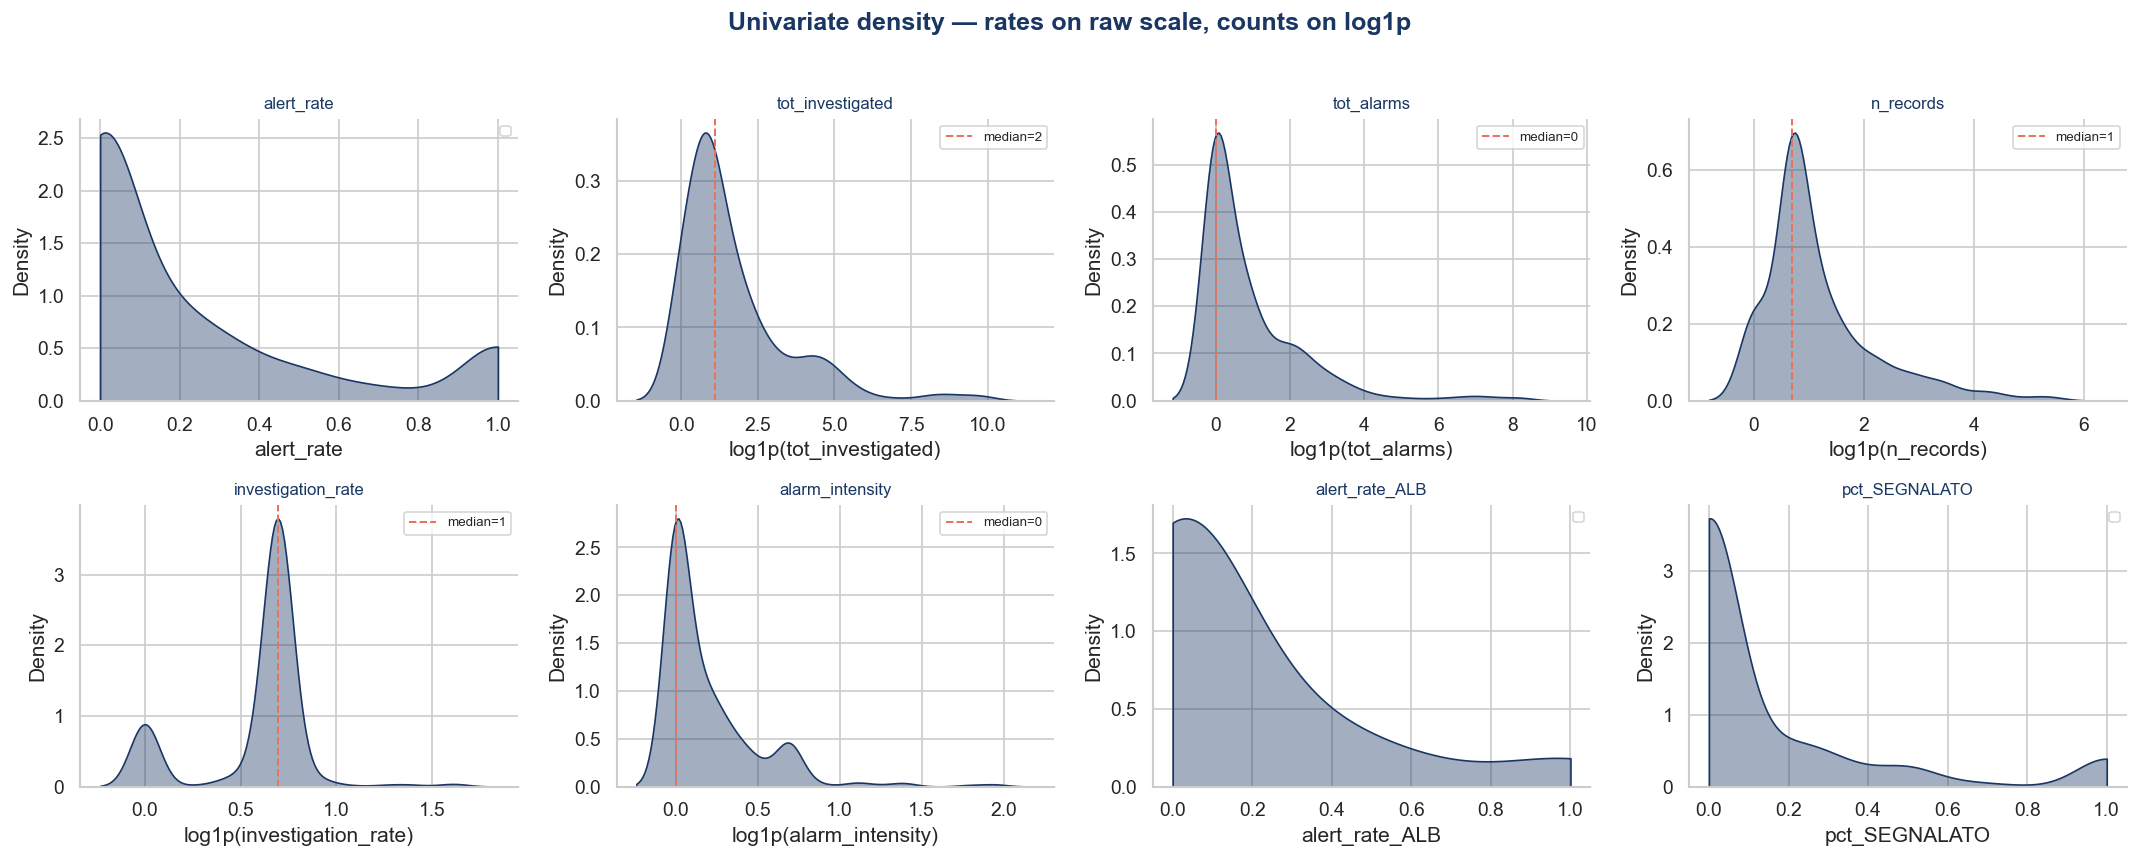

In [542]:
plot_feats = ['alert_rate', 'tot_investigated', 'tot_alarms', 'tot_entries',
              'n_records', 'investigation_rate', 'alarm_intensity'] + \
             [f'alert_rate_{top_nat[0]}', f'pct_{top_co[0]}']
plot_feats = [c for c in plot_feats if c in df_route.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, c in zip(axes.flatten(), plot_feats):
    s = df_route[c].dropna()
    is_rate = c.startswith(('alert_rate', 'pct_'))
    if is_rate:
        sns.kdeplot(s, ax=ax, color=NAVY, fill=True, alpha=0.4, clip=(0, 1))
    else:
        sns.kdeplot(np.log1p(s), ax=ax, color=NAVY, fill=True, alpha=0.4)
        ax.set_xlabel(f'log1p({c})')
        ax.axvline(np.log1p(s.median()), color=CORAL, ls='--', lw=1.2,
                   label=f'median={int(s.median())}')
    ax.set_title(c, color=NAVY, fontsize=10)
    ax.legend(fontsize=8, loc='upper right'); sns.despine(ax=ax)
plt.suptitle('Univariate density — rates on raw scale, counts on log1p',
             fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout(); plt.show()

## 4. Bivariate analysis

Single scatter answering the central question of the project: do high alert-rate routes also have high volumes, or are they low-volume artifacts? Bubble size encodes absolute alarms; the median rate line is the cross-sectional reference.

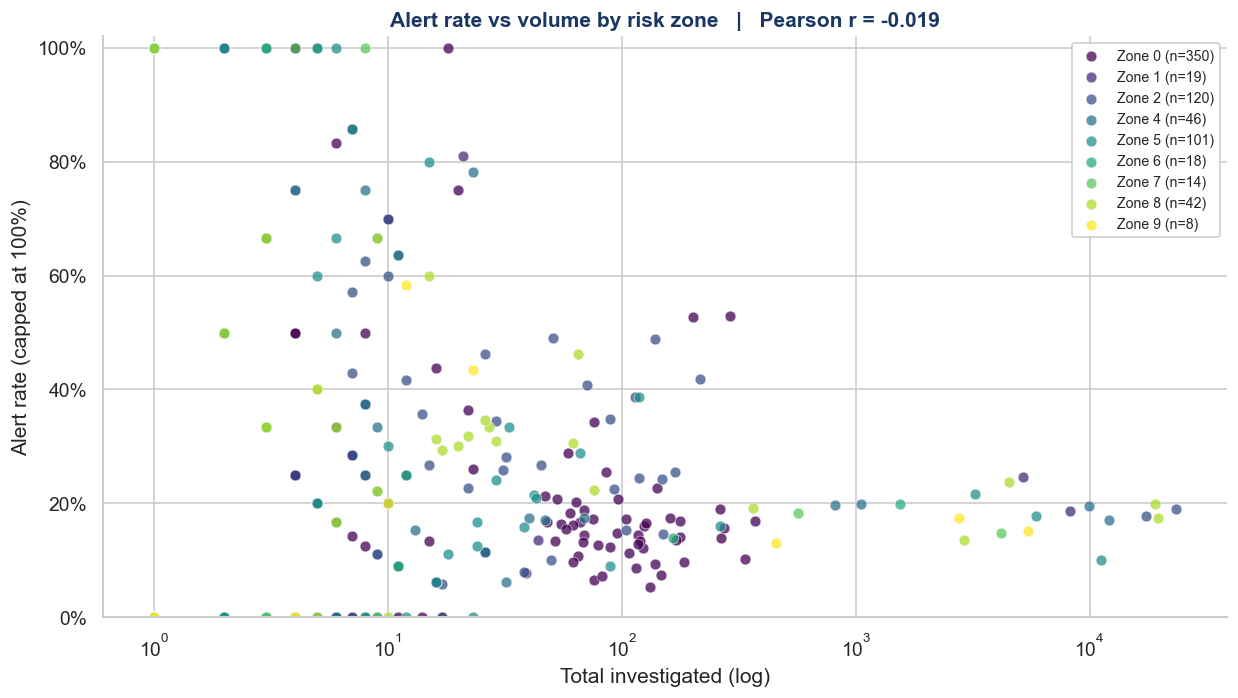

In [543]:
median_rate = df_route['alert_rate'].median()

# Sequential colormap on ZONE — natural ordering 0→9
zones_sorted = sorted([z for z in df_route['ZONE'].dropna().unique()])
cmap = plt.cm.viridis
zone_colors = {z: cmap(i / max(len(zones_sorted)-1, 1)) for i, z in enumerate(zones_sorted)}

pearson_r = df_route['tot_investigated'].corr(df_route['alert_rate'])

fig, ax = plt.subplots(figsize=(10.5, 6))
for z in zones_sorted:
    sub = df_route[df_route['ZONE'] == z]
    ax.scatter(sub['tot_investigated'].clip(lower=1), sub['alert_rate'],
               c=[zone_colors[z]], s=42, alpha=0.75,
               edgecolor='white', linewidth=0.4,
               label=f'Zone {int(z)} (n={len(sub)})')
no_zone = df_route[df_route['ZONE'].isna()]
if len(no_zone) > 0:
    ax.scatter(no_zone['tot_investigated'].clip(lower=1), no_zone['alert_rate'],
               c='lightgrey', s=25, alpha=0.5, marker='x',
               label=f'No zone (n={len(no_zone)})')

ax.set_xscale('log'); ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xlabel('Total investigated (log)'); ax.set_ylabel('Alert rate (capped at 100%)')
ax.set_title(f'Alert rate vs volume by risk zone   |   Pearson r = {pearson_r:+.3f}',
             fontweight='bold', color=NAVY)
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.95, ncol=1)
sns.despine(); plt.tight_layout(); plt.show()

## 5. Multivariate analysis

Lower-triangular Pearson matrix on the engineered numeric features; flags multi-collinearity that would dominate distance-based detectors (LOF, DBSCAN) if left unaddressed.

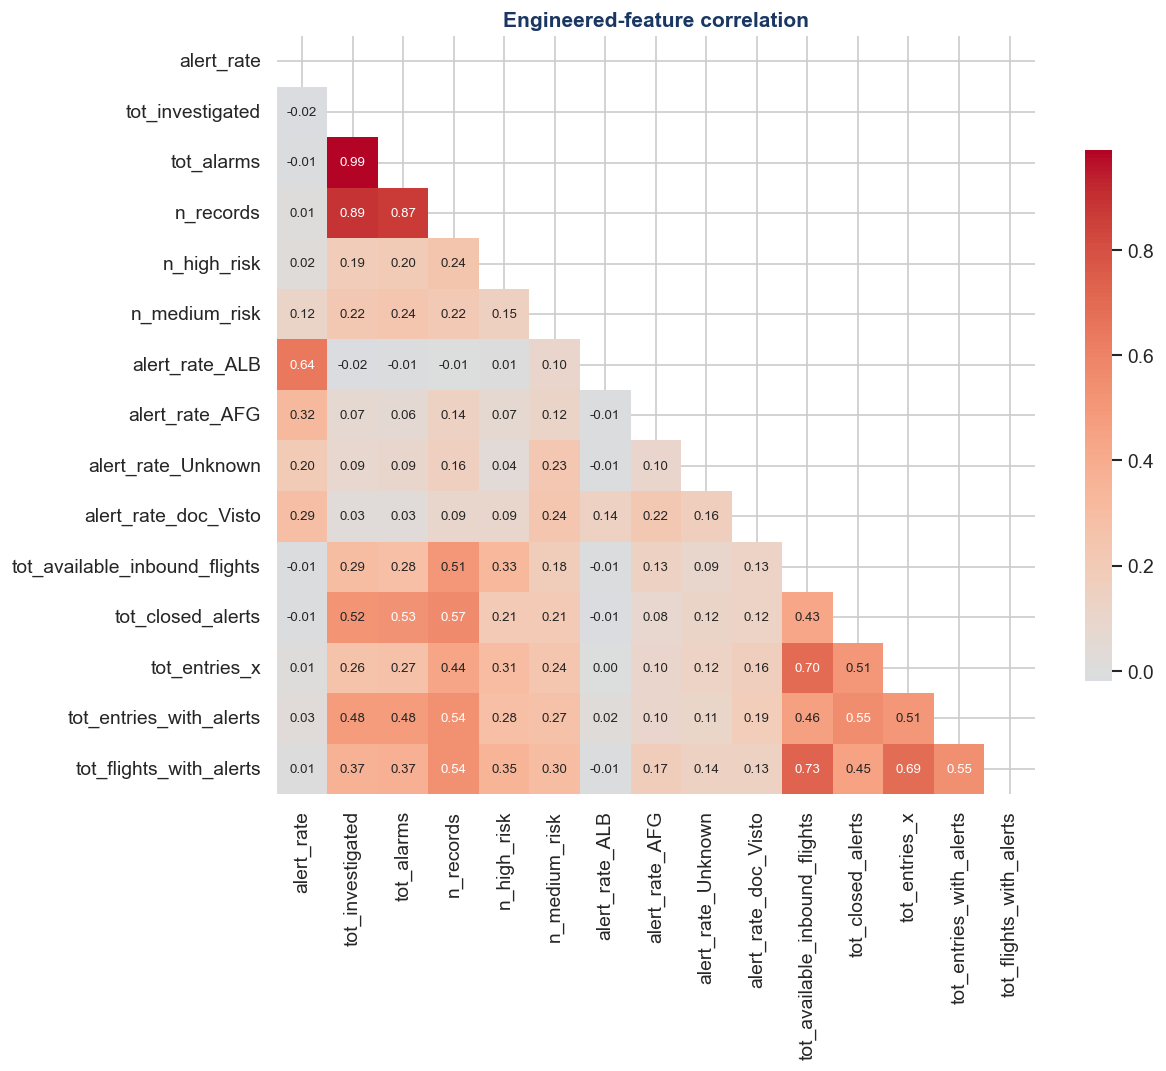

In [544]:
mv_cols = (['alert_rate','tot_investigated','tot_alarms','tot_entries','n_records',
            'n_high_risk','n_medium_risk']
           + [c for c in df_route.columns if c.startswith('alert_rate_')][:4]
           + [c for c in df_route.columns if c.startswith('tot_') 
              and c not in ('tot_entries','tot_investigated','tot_alarms')][:5])
mv_cols = [c for c in mv_cols if c in df_route.columns]
corr = df_route[mv_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.7}, annot_kws={'size': 8})
plt.title('Engineered-feature correlation', fontweight='bold', color=NAVY)
plt.tight_layout(); plt.show()

### 5.2 Pair plot — selected features

Four features picked for semantic distance: a global rate, a volume, a risk-weighted count, a segmented rate (top nationality), an outcome proportion. Diagonal = KDE marginal; off-diagonal = pairwise scatter. Reveals non-linear relationships and clusters that the heatmap collapses into a single number.

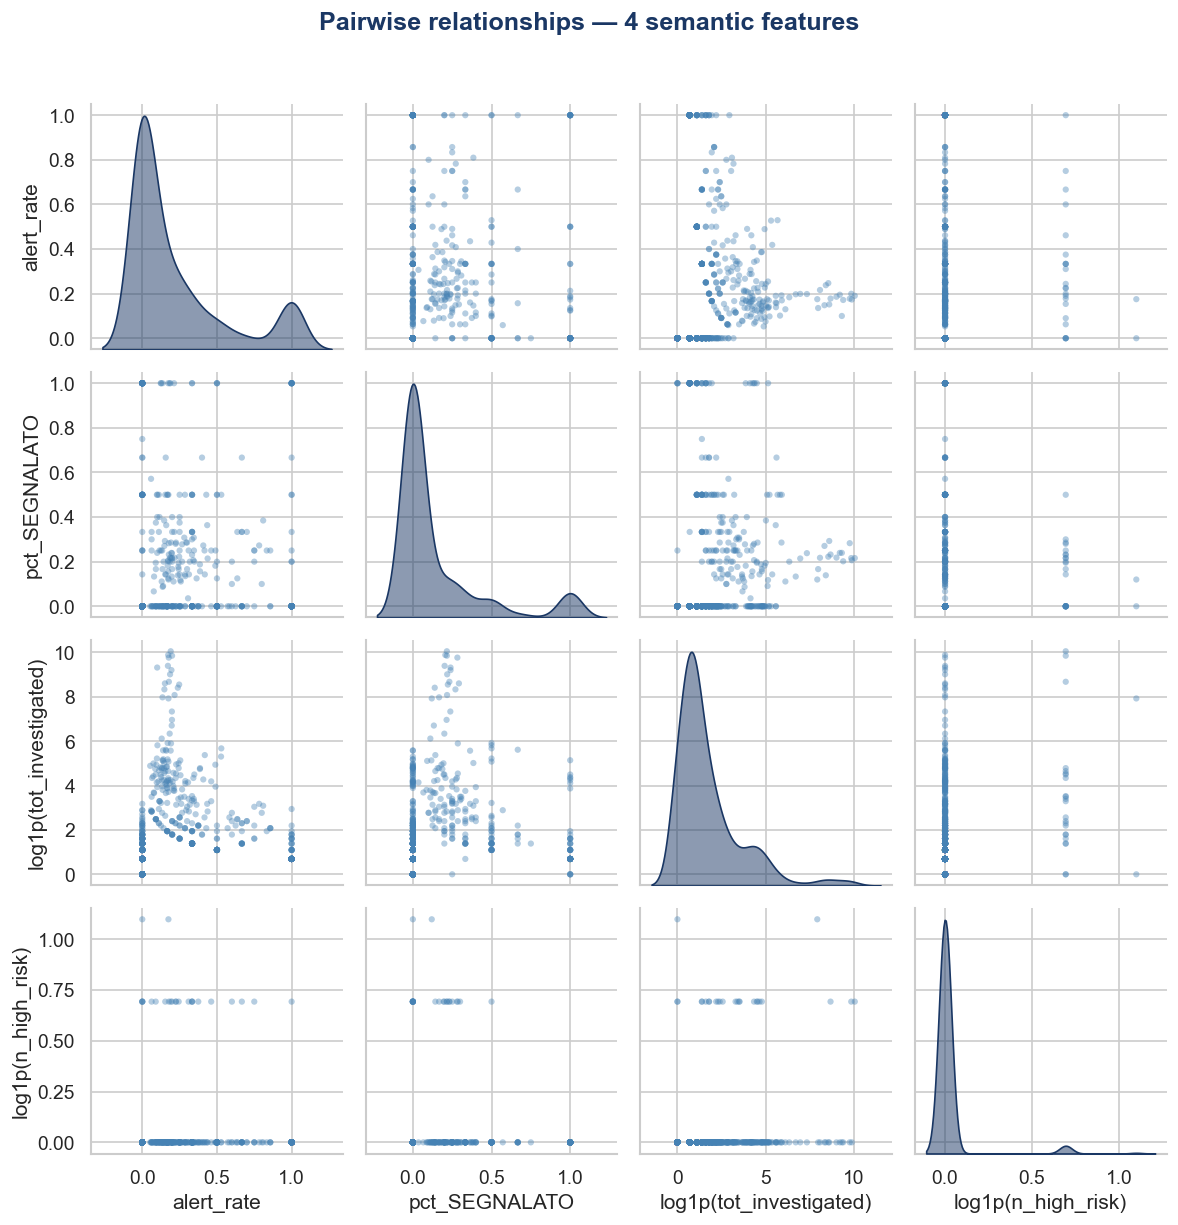

(None, None)

In [545]:
pair_feats = ['alert_rate', 'tot_investigated', 'n_high_risk', f'pct_{top_co[0]}']
pair_feats = [c for c in pair_feats if c in df_route.columns]

sample = df_route[pair_feats].copy()
for c in ['tot_investigated', 'n_high_risk']:
    if c in sample.columns:
        sample[f'log1p({c})'] = np.log1p(sample[c])
        sample = sample.drop(columns=c)
if len(sample) > 800:
    sample = sample.sample(800, random_state=RANDOM_STATE)

g = sns.pairplot(sample, diag_kind='kde',
                 plot_kws={'alpha': 0.4, 'color': STEEL, 's': 14, 'edgecolor': 'none'},
                 diag_kws={'color': NAVY, 'fill': True, 'alpha': 0.5})
g.figure.suptitle('Pairwise relationships — 4 semantic features',
                  fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout(), plt.show()

## 6. Outlier analysis — robust modified Z-score

Standard 1.5·IQR is unsuited to right-skewed count data: it flags an entire shoulder of the distribution as anomalous. We adopt the modified Z-score on the log1p-transformed values: z_mod = 0.6745 · (x − median) / MAD, with MAD the median absolute deviation. The transformation tames the skew; MAD is robust to the same outliers we are trying to flag (unlike the standard deviation, which they would inflate). Threshold |z_mod| > 3.5 follows Iglewicz & Hoaglin (1993). The result is a descriptive flag — these rows are not removed; they remain the signal the detector must learn.

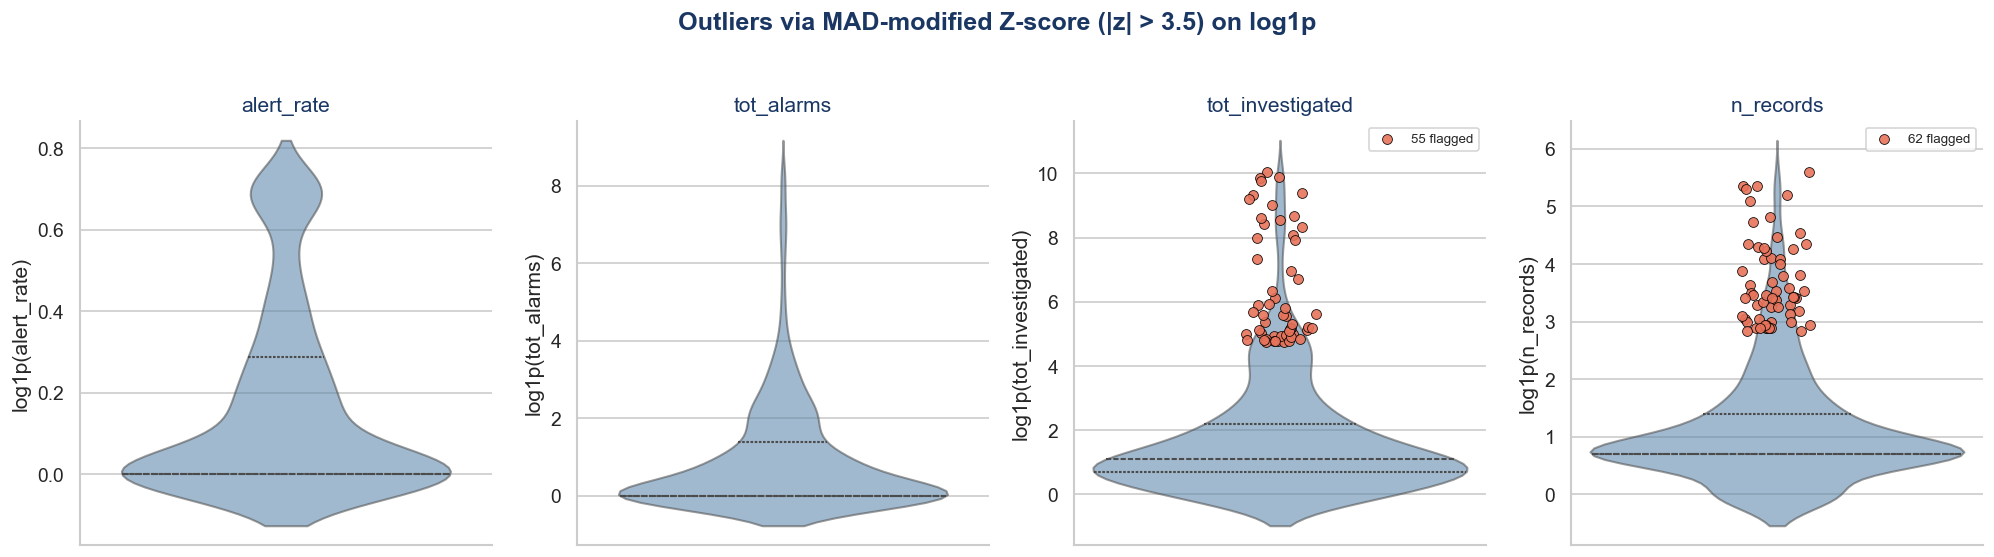

,median_raw,MAD_log,n_flagged,%
col,,,,
alert_rate,0.00,0.00,0,0.00
tot_alarms,0.00,0.00,0,0.00
tot_investigated,2.00,0.69,55,7.66
n_records,1.00,0.41,62,8.64


In [546]:
def mad_modified_zscore(series, threshold=3.5):
    """MAD-based modified Z-score on log1p-transformed series.
    Robust to skewness and to the outliers themselves."""
    s = np.log1p(series.dropna())
    med = s.median()
    mad = np.median(np.abs(s - med))
    if mad == 0:
        return pd.Series(False, index=series.index), pd.Series(np.nan, index=series.index)
    mod_z = 0.6745 * (s - med) / mad
    flagged = pd.Series(False, index=series.index)
    flagged.loc[mod_z.index] = np.abs(mod_z) > threshold
    z_full = pd.Series(np.nan, index=series.index)
    z_full.loc[mod_z.index] = mod_z.values
    return flagged, z_full

outlier_cols = ['alert_rate', 'tot_alarms', 'tot_investigated', 'n_records']
flags, zscores = {}, {}
for c in outlier_cols:
    flags[c], zscores[c] = mad_modified_zscore(df_route[c])

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(4.2*len(outlier_cols), 4.5))
for ax, c in zip(axes, outlier_cols):
    s_log = np.log1p(df_route[c].dropna())
    sns.violinplot(y=s_log, ax=ax, color=STEEL, inner='quartile', alpha=0.55)
    flagged_idx = flags[c][flags[c]].index
    if len(flagged_idx) > 0:
        flagged_y = np.log1p(df_route.loc[flagged_idx, c])
        jitter = np.random.uniform(-0.08, 0.08, len(flagged_y))
        ax.scatter(jitter, flagged_y, color=CORAL, s=35,
                   edgecolor='black', linewidths=0.5, zorder=3, alpha=0.9,
                   label=f'{flags[c].sum()} flagged')
        ax.legend(fontsize=8, loc='upper right')
    ax.set_title(c, color=NAVY); ax.set_ylabel(f'log1p({c})')
    sns.despine(ax=ax)
plt.suptitle('Outliers via MAD-modified Z-score (|z| > 3.5) on log1p',
             fontweight='bold', color=NAVY, y=1.03)
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    'col': outlier_cols,
    'median_raw': [df_route[c].median() for c in outlier_cols],
    'MAD_log':    [np.median(np.abs(np.log1p(df_route[c].dropna())
                   - np.log1p(df_route[c].dropna()).median()))
                   for c in outlier_cols],
    'n_flagged':  [int(flags[c].sum()) for c in outlier_cols],
    '%':          [round(flags[c].sum() / len(df_route) * 100, 2) for c in outlier_cols],
}).set_index('col')
display(summary)

## 7. Feature engineering

The four detectors operate on a numeric matrix. We need three things from it:   
(i) a deterministic, auto-adapting feature selection so the pipeline does not break when the upstream segmentation changes;   
(ii) a transform that compresses the right-skew typical of count features without distorting bounded rates;   
(iii) a scaling that puts every feature on the same dispersion, so distance-based detectors weigh them comparably.

### 7.1 Feature selection — by prefix, deterministic
The columns are picked by **prefix match** (`tot_*`, `alert_rate*`, `pct_*`, `n_*risk`) rather than hardcoded names.   
This means: when the §2.8
auto-detection finds a different set of top nationalities or document
types, the feature list adjusts automatically — no silent drift.

In [547]:
count_features = [c for c in df_route.columns if c.startswith('tot_')]
rate_features  = [c for c in df_route.columns
                  if c.startswith('alert_rate') or c.startswith('pct_')]
risk_features  = [c for c in ['n_high_risk', 'n_medium_risk'] if c in df_route.columns]
feature_cols = count_features + rate_features + risk_features + ['alarm_intensity', 'investigation_rate']
feature_cols = [c for c in feature_cols if c in df_route.columns]
print(f'Total features : {len(feature_cols)}')
print(f'  Counts ({len(count_features):>2}) : {count_features[:5]} ...')
print(f'  Rates  ({len(rate_features):>2}) : {rate_features[:5]} ...')
print(f'  Risk   ({len(risk_features):>2}) : {risk_features}')

Total features : 34
  Counts (17) : ['tot_available_inbound_flights', 'tot_closed_alerts', 'tot_entries_x', 'tot_entries_with_alerts', 'tot_flights_with_alerts'] ...
  Rates  (13) : ['alert_rate', 'alert_rate_ALB', 'pct_nat_ALB', 'alert_rate_AFG', 'pct_nat_AFG'] ...
  Risk   ( 2) : ['n_high_risk', 'n_medium_risk']


### 7.2 log1p compression of count skew
Count features (`tot_*`, `n_*risk`) are right-skewed and zero-inflated:  
peak at 0, long tail to thousands. On linear scale the detectors would mostly rank by raw magnitude — losing the relative-deviation signal.  

`log1p(x) = log(1 + x)` solves both: handles zeros without diverging (unlike `log`), and compresses the tail.   
A route with 10 000 alarms ends upat ≈9.2; one with 100 alarms at ≈4.6 — distance shrinks from 9 900 to 4.6, the right scale for distance-based methods (LOF, DBSCAN).  

Applied uniformly: rate features are bounded in [0, 1], so `log1p` is nearly the identity on them (`log1p(0.5) ≈ 0.41`) — no harm done.   
We verify the skewness drop below.

In [548]:
from scipy.stats import skew

X = df_route[feature_cols].fillna(0).astype(float)
X_log = np.log1p(X.values)

skew_before = pd.Series(skew(X.values), index=feature_cols).abs()
skew_after  = pd.Series(skew(X_log),     index=feature_cols).abs()
print(f"|Skewness| mean   : {skew_before.mean():.2f}  ->  {skew_after.mean():.2f}")
print(f"|Skewness| max    : {skew_before.max():.2f}  ->  {skew_after.max():.2f}")
print(f"Features with |skew|>2 (severely skewed):")
print(f"   before log1p: {(skew_before > 2).sum()} -> {len(feature_cols)}")
print(f"   after  log1p: {(skew_after  > 2).sum()} -> {len(feature_cols)}")

|Skewness| mean   : 6.05  ->  3.44
|Skewness| max    : 26.70  ->  18.28
Features with |skew|>2 (severely skewed):
   before log1p: 30 -> 34
   after  log1p: 18 -> 34


### 7.3 Standardisation — the cross-sectional baseline
After scaling, every value is *"how many standard deviations from the population mean"* — a z-score relative to the cross-sectional baseline.  
This is exactly the reference distribution the brief calls for, given that the 2-month window does not support a temporal baseline.  

This step is what allows LOF and DBSCAN to weigh all features comparably:   
without it, `tot_investigated` (range 0–10⁴ even after log1p) would dominate `alert_rate` (range 0–1) by orders of magnitude in any Euclidean distance, and the rate signal would be invisible to them.  

Isolation Forest is scale-invariant — its splits use one feature at a time — but we feed it the same matrix for code consistency.

In [549]:
from sklearn.preprocessing import StandardScaler

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_log),
                        columns=feature_cols, index=X.index)

print(f'X_scaled shape    : {X_scaled.shape}')
print(f'Mean over matrix  : {X_scaled.values.mean():.6f}  (target ≈ 0)')
print(f'Std  over matrix  : {X_scaled.values.std():.6f}   (target ≈ 1)')
print(f'\nPer-feature std (first 5):')
print(X_scaled.std().head().round(3).to_string())

X_scaled shape    : (718, 34)
Mean over matrix  : 0.000000  (target ≈ 0)
Std  over matrix  : 1.000000   (target ≈ 1)

Per-feature std (first 5):
tot_available_inbound_flights   1.00
tot_closed_alerts               1.00
tot_entries_x                   1.00
tot_entries_with_alerts         1.00
tot_flights_with_alerts         1.00


## 8. Anomaly detection — four-detector ensemble

Four independent biases: random isolation (IF), local density (LOF), density connectivity (DBSCAN), parametric tail (Z-score). A route reaches consensus with ≥ 2/4 votes — stricter than a single detector, less brittle than full unanimity.

In [550]:
# 1) Isolation Forest
iso = IsolationForest(n_estimators=200, contamination=CONTAMINATION,
                      random_state=RANDOM_STATE).fit(X_scaled)
df_route['if_score']   = -iso.decision_function(X_scaled)
df_route['if_anomaly'] = (iso.predict(X_scaled) == -1).astype(int)

# 2) LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION)
df_route['lof_anomaly'] = (lof.fit_predict(X_scaled) == -1).astype(int)
df_route['lof_score']   = -lof.negative_outlier_factor_

# 3) DBSCAN — eps from 95th-percentile k-distance, min_samples = 2*d
d = X_scaled.shape[1]; min_samples = 2*d
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
k_dist = np.sort(nn.kneighbors(X_scaled)[0][:, -1])
eps = float(np.quantile(k_dist, 0.95))
db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
df_route['dbscan_anomaly'] = (db.labels_ == -1).astype(int)

# 4) Z-score on the standardised matrix (max |z| > 3 across features)
Z = np.abs(stats.zscore(X_scaled.values, ddof=1))
df_route['z_max']     = Z.max(axis=1)
df_route['z_anomaly'] = (df_route['z_max'] > 3).astype(int)

# Vote ≥ 2/4
det_cols = ['if_anomaly','lof_anomaly','dbscan_anomaly','z_anomaly']
df_route['anomaly_votes']     = df_route[det_cols].sum(axis=1)
df_route['anomaly_consensus'] = (df_route['anomaly_votes'] >= 2).astype(int)

print('Per-detector flags:'); print(df_route[det_cols].sum().to_string())
print(f"\nVote distribution:\n{df_route['anomaly_votes'].value_counts().sort_index().to_string()}")
print(f"\nDBSCAN params: eps={eps:.3f}, min_samples={min_samples}")
print(f"Consensus (≥2/4): {df_route['anomaly_consensus'].sum()} routes")

Per-detector flags:
if_anomaly         36
lof_anomaly        36
dbscan_anomaly     11
z_anomaly         221

Vote distribution:
anomaly_votes
0    463
1    210
2     41
3      4

DBSCAN params: eps=9.951, min_samples=68
Consensus (≥2/4): 45 routes


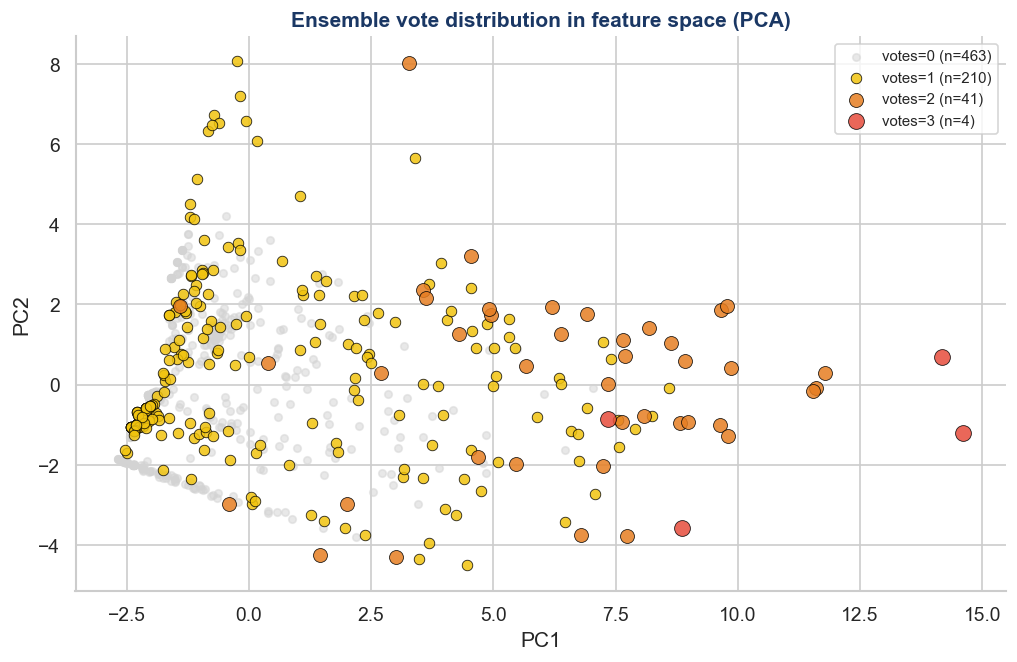

In [551]:
from sklearn.decomposition import PCA
pc = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(pc[df_route['anomaly_votes']==0, 0], pc[df_route['anomaly_votes']==0, 1],
            c='lightgrey', s=20, alpha=0.5, label=f"votes=0 (n={(df_route['anomaly_votes']==0).sum()})")
for v, color, size in [(1,'#F1C40F',40), (2,'#E67E22',70), (3,'#E74C3C',90), (4,'#8B0000',120)]:
    m = df_route['anomaly_votes'] == v
    if m.any():
        plt.scatter(pc[m, 0], pc[m, 1], c=color, s=size, alpha=0.85,
                    edgecolor='black', linewidths=0.5, label=f'votes={v} (n={m.sum()})')
plt.xlabel(f'PC1'); plt.ylabel(f'PC2')
plt.title('Ensemble vote distribution in feature space (PCA)', fontweight='bold', color=NAVY)
plt.legend(loc='best', fontsize=9); sns.despine(); plt.show()

## 8.1 Sensitivity analysis on contamination

The contamination parameter encodes the prior on anomaly rate for IF and LOF.   
We chose 0.05 to match the order of magnitude of the Whitehall brief examples; this section makes the choice empirically defensible by sweeping contamination ∈ {0.03, 0.05, 0.07, 0.10} and tracking how per-detector flags and consensus counts evolve.   
DBSCAN and Z-score have their own independent thresholds and stay static across the sweep — the consensus moves only because of the IF/LOF re-fit.

,contamination,IF,LOF,IF∩LOF,DBSCAN,Z,consensus_>=2,consensus_>=3
0,0.03,22,22,0,11,221,29,4
1,0.05,36,36,0,11,221,45,4
2,0.07,51,51,0,11,221,57,8
3,0.10,72,72,1,11,221,80,9


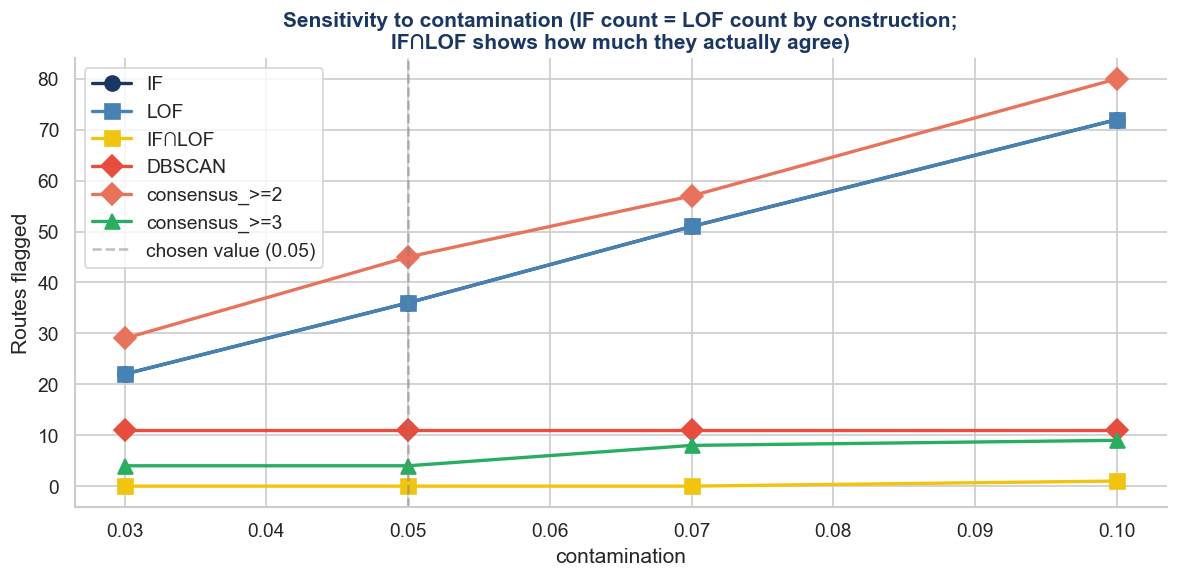


Delta consensus_>=2 across the sweep: 51 routes (29 -> 80)


In [552]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

contamination_grid = [0.03, 0.05, 0.07, 0.10]
db_static = df_route['dbscan_anomaly'].values
z_static  = df_route['z_anomaly'].values

sens_rows = []
for c in contamination_grid:
    iso_c = IsolationForest(n_estimators=200, contamination=c,
                            random_state=RANDOM_STATE).fit(X_scaled)
    lof_c = LocalOutlierFactor(n_neighbors=20, contamination=c)
    if_flag  = (iso_c.predict(X_scaled) == -1).astype(int)
    lof_flag = (lof_c.fit_predict(X_scaled) == -1).astype(int)
    if_set  = set(np.where(if_flag  == 1)[0])
    lof_set = set(np.where(lof_flag == 1)[0])
    if_lof_intersection = len(if_set & lof_set)
    votes = if_flag + lof_flag + db_static + z_static
    sens_rows.append({
        'contamination': c,
        'IF':  int(if_flag.sum()),
        'LOF': int(lof_flag.sum()),
        'IF∩LOF': if_lof_intersection,
        'DBSCAN': int(db_static.sum()), 'Z': int(z_static.sum()),
        'consensus_>=2': int((votes >= 2).sum()),
        'consensus_>=3': int((votes >= 3).sum()),
    })

sens_df = pd.DataFrame(sens_rows)
display(sens_df)

fig, ax = plt.subplots(figsize=(10, 5))
for col, color, marker in [('IF', NAVY, 'o'), ('LOF', STEEL, 's'),
                           ('IF∩LOF', GOLD, 's'),
                            ('DBSCAN', RED, 'D'),
                           ('consensus_>=2', CORAL, 'D'),
                           ('consensus_>=3', GREEN, '^')]:
    ax.plot(sens_df['contamination'], sens_df[col],
            color=color, marker=marker, linewidth=2, markersize=9, label=col)
ax.axvline(0.05, color='gray', ls='--', alpha=0.5, label='chosen value (0.05)')
ax.set_xlabel('contamination'); ax.set_ylabel('Routes flagged')
ax.set_title('Sensitivity to contamination (IF count = LOF count by construction;\n'
             'IF∩LOF shows how much they actually agree)',
             fontweight='bold', color=NAVY)
ax.legend(); sns.despine(); plt.tight_layout(); plt.show()

print(f"\nDelta consensus_>=2 across the sweep: "
      f"{sens_df['consensus_>=2'].max() - sens_df['consensus_>=2'].min()} routes "
      f"({sens_df['consensus_>=2'].min()} -> {sens_df['consensus_>=2'].max()})")

## 9. Post-processing — operational ranking

Three layers on the consensus subset: (i) risk_level from rate × volume × votes, (ii) Wilson 95 % CI on the alert rate (handles small-volume routes), (iii) priority_score = 0.60·rate_norm + 0.40·log(absolute_alarms)_norm. Output stratified into a transit anomaly report.

In [553]:
df_post = df_route[df_route['anomaly_consensus'] == 1].copy()
print(f'Consensus routes: {len(df_post)}')

# Cross-sectional anchor (population-wide)
pop_median_rate = df_route['alert_rate'].median()

# Self-calibrating anchors (consensus subset tertiles)
post_rate_p66   = df_post['alert_rate'].quantile(0.66)
post_rate_p33   = df_post['alert_rate'].quantile(0.33)
post_volume_p25 = df_post['tot_investigated'].quantile(0.25)

# Take the more conservative of the two anchors
T_HIGH = max(3.0 * pop_median_rate, post_rate_p66)
T_MED  = max(1.5 * pop_median_rate, post_rate_p33)
T_VOL  = max(2,   post_volume_p25)

print(f"\nThresholds (max of cross-sectional and tertile-based):")
print(f"  T_HIGH (rate)   : {T_HIGH:.3f}   "
      f"[3x pop median = {3*pop_median_rate:.3f}, P66 consensus = {post_rate_p66:.3f}]")
print(f"  T_MED  (rate)   : {T_MED:.3f}   "
      f"[1.5x pop median = {1.5*pop_median_rate:.3f}, P33 consensus = {post_rate_p33:.3f}]")
print(f"  T_VOL  (min)    : {T_VOL:.0f}    "
      f"[P25 consensus volume = {post_volume_p25:.0f}]")

def classify_risk(r):
    if r['anomaly_votes'] == 4:
        return 'CRITICAL'
    if r['alert_rate'] >= T_HIGH and r['tot_investigated'] >= T_VOL:
        return 'HIGH'
    if r['anomaly_votes'] >= 3 and r['alert_rate'] >= pop_median_rate:
        return 'HIGH'
    if r['alert_rate'] >= T_MED or r['anomaly_votes'] >= 3:
        return 'MEDIUM'
    return 'LOW'

df_post['risk_level'] = df_post.apply(classify_risk, axis=1)

print(df_post['risk_level']
      .value_counts()
      .reindex(['CRITICAL','HIGH','MEDIUM','LOW']).fillna(0).astype(int).to_string())

def quality_note(r):
    rate, vol = r['alert_rate'], r['tot_investigated']
    if vol == 0 and rate > 0:        return 'incomplete data — alarms but no traveler records'
    if rate == 0 and vol <= 2:       return 'likely false positive — flagged on non-rate features'
    if rate >= 0.30 and vol <= 3:    return 'warning — high rate but tiny volume (≤3 investigated)'
    return 'ok'

def wilson_ci(rate, n, z=1.96):
    if n == 0: return np.nan, np.nan
    k = round(rate*n)
    centre = (k + z*z/2) / (n + z*z)
    margin = z * np.sqrt(k*(n-k)/n + z*z/4) / (n + z*z)
    return max(0, centre - margin), min(1, centre + margin)

df_post['risk_level']   = df_post.apply(classify_risk, axis=1)
df_post['quality_note'] = df_post.apply(quality_note, axis=1)
ci = df_post.apply(lambda r: wilson_ci(r['alert_rate'], int(r['tot_investigated'])), axis=1)
df_post[['ci95_low','ci95_high']] = pd.DataFrame(ci.tolist(), index=df_post.index)
df_post['ci95_str'] = df_post.apply(
    lambda r: f"[{r['ci95_low']:.1%}, {r['ci95_high']:.1%}]"
              if pd.notna(r['ci95_low']) else 'n/a', axis=1)

from sklearn.preprocessing import MinMaxScaler
df_post['absolute_alarms']     = df_post['alert_rate'] * df_post['tot_investigated']
df_post['absolute_alarms_log'] = np.log1p(df_post['absolute_alarms'])

pop_rate_min, pop_rate_max = df_route['alert_rate'].min(), df_route['alert_rate'].max()
df_post['rate_n'] = ((df_post['alert_rate'] - pop_rate_min)
                     / max(pop_rate_max - pop_rate_min, 1e-9))
df_post['alarms_n'] = MinMaxScaler().fit_transform(df_post[['absolute_alarms_log']])
df_post['ci_width']   = df_post['ci95_high'] - df_post['ci95_low']
df_post['confidence'] = (1 - df_post['ci_width']).clip(lower=0).fillna(0)

# Priority = magnitude × confidence
df_post['priority_score'] = ((0.60 * df_post['rate_n'] + 0.40 * df_post['alarms_n'])
                              * df_post['confidence']).round(4)

# Sort PURELY by priority_score (no risk_level pre-grouping — let the score speak)
df_post = df_post.sort_values('priority_score', ascending=False).reset_index(drop=True)
df_post['rank'] = df_post.index + 1

print(df_post[['rank','route','risk_level','alert_rate','tot_investigated',
               'ci95_str','confidence','priority_score']].head(20).to_string(index=False))


Consensus routes: 45

Thresholds (max of cross-sectional and tertile-based):
  T_HIGH (rate)   : 0.409   [3x pop median = 0.000, P66 consensus = 0.409]
  T_MED  (rate)   : 0.195   [1.5x pop median = 0.000, P33 consensus = 0.195]
  T_VOL  (min)    : 5    [P25 consensus volume = 5]
risk_level
CRITICAL     0
HIGH        15
MEDIUM      17
LOW         13
 rank   route risk_level  alert_rate  tot_investigated        ci95_str  confidence  priority_score
    1 TIA→BGY       HIGH        0.19          23288.00  [18.5%, 19.5%]        0.99            0.51
    2 TIA→BLQ       HIGH        0.20          19072.00  [19.4%, 20.5%]        0.99            0.51
    3 TIA→PSA        LOW        0.17          19686.00  [16.8%, 17.9%]        0.99            0.49
    4 TIA→MXP        LOW        0.18          17487.00  [17.2%, 18.3%]        0.99            0.48
    5 IST→CTA       HIGH        1.00              8.00 [67.6%, 100.0%]        0.68            0.48
    6 TIA→AOI     MEDIUM        0.24           4503.00

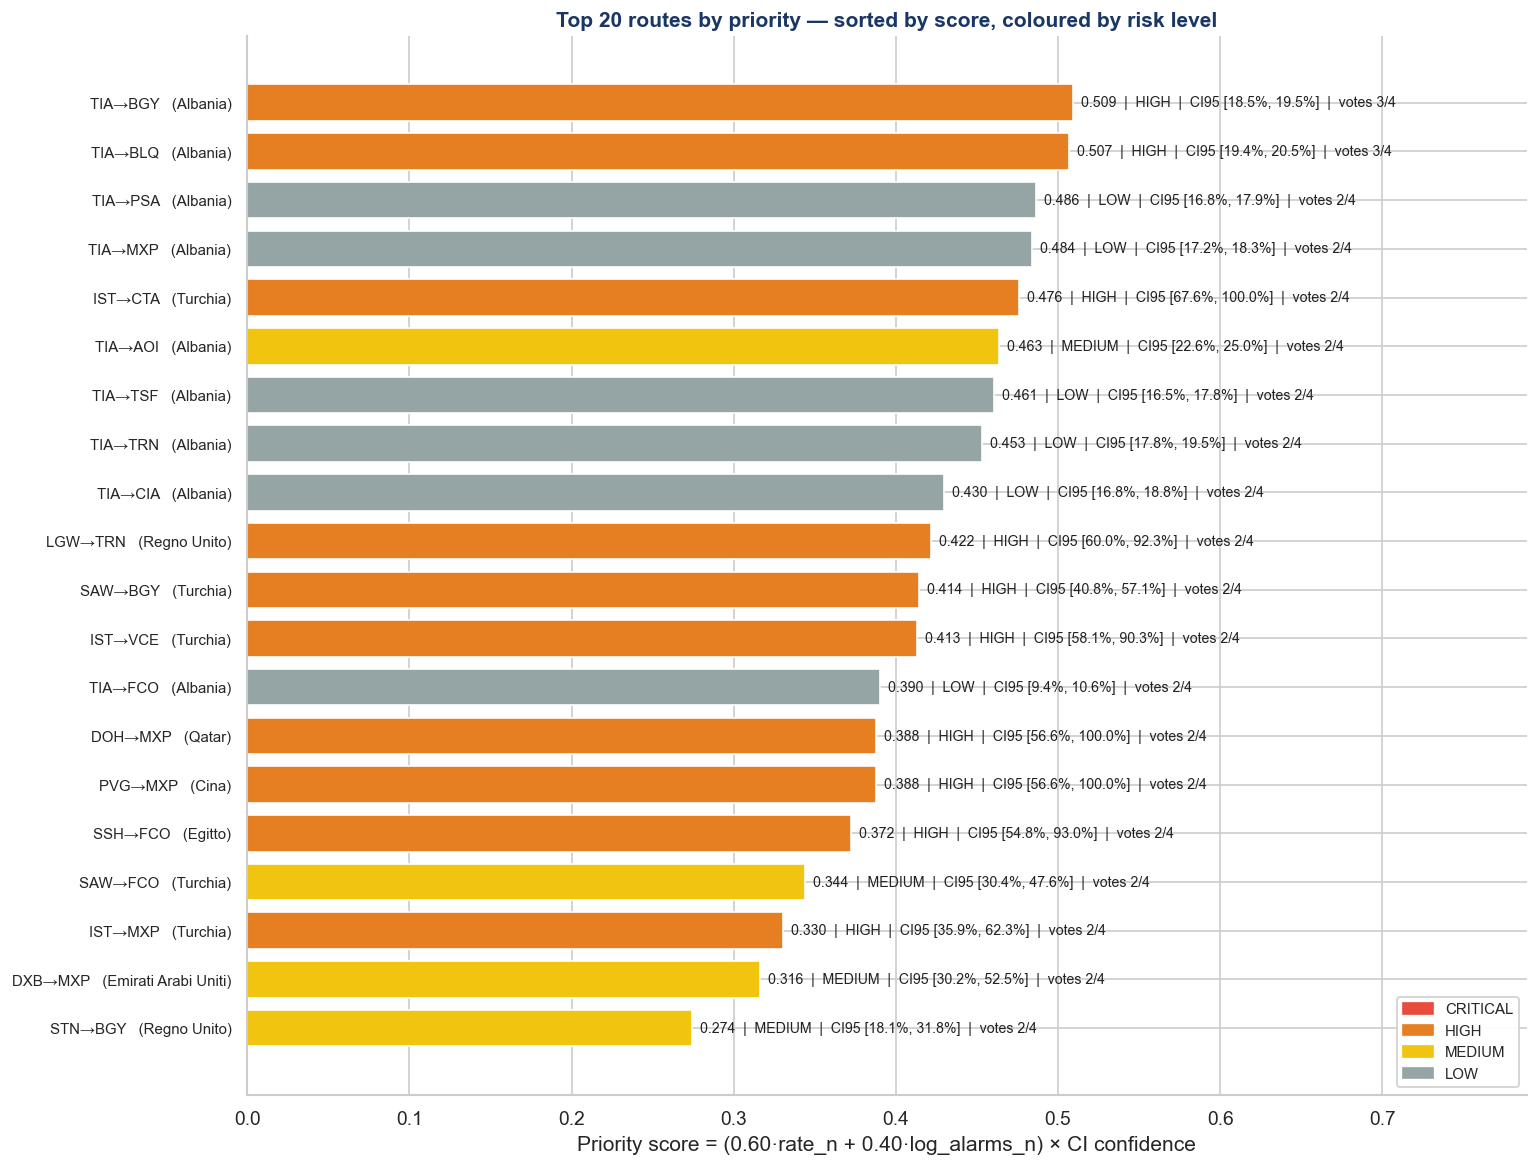

In [554]:
df_clean = df_post[~df_post['quality_note'].isin([
    'incomplete data — alarms but no traveler records',
    'likely false positive — flagged on non-rate features'])]

color_map = {'CRITICAL':'#E74C3C', 'HIGH':'#E67E22',
             'MEDIUM':'#F1C40F',   'LOW':'#95A5A6'}

N_SHOW = min(20, len(df_clean))
df_plot = df_clean.head(N_SHOW).iloc[::-1]
labels = (df_plot['route'] + '   ('
          + df_plot['DEPARTURE_COUNTRY'].fillna('n/a').astype(str) + ')')

fig, ax = plt.subplots(figsize=(13, 0.42 * N_SHOW + 1.5))
ax.barh(range(N_SHOW), df_plot['priority_score'],
        color=[color_map[l] for l in df_plot['risk_level']],
        edgecolor='white', height=0.75)

for i, (sc, ci, vt, lvl, qn) in enumerate(zip(df_plot['priority_score'],
                                               df_plot['ci95_str'],
                                               df_plot['anomaly_votes'],
                                               df_plot['risk_level'],
                                               df_plot['quality_note'])):
    suffix = '  ⚠' if qn != 'ok' else ''
    ax.text(sc + 0.005, i,
            f'{sc:.3f}  |  {lvl}  |  CI95 {ci}  |  votes {int(vt)}/4{suffix}',
            va='center', fontsize=8.5, color='#222')

ax.set_yticks(range(N_SHOW))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Priority score = (0.60·rate_n + 0.40·log_alarms_n) × CI confidence')
ax.set_title(f'Top {N_SHOW} routes by priority — sorted by score, coloured by risk level',
             fontweight='bold', color=NAVY)
ax.set_xlim(0, max(df_plot['priority_score'].max() * 1.55, 0.1))

from matplotlib.patches import Patch
patches = [Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9, framealpha=0.95)
sns.despine(); plt.tight_layout(); plt.show()

In [561]:
print(f"""
  Routes analyzed       : {len(df_route)}
  ≥1 detector flagged   : {(df_route['anomaly_votes']>=1).sum()}
  Consensus (≥2/4)      : {len(df_post)}
  Reliable in report    : {len(df_clean)}
  Excluded (data QA)    : {len(df_post) - len(df_clean)}

  CRITICAL : {(df_post['risk_level']=='CRITICAL').sum()}
  HIGH     : {(df_post['risk_level']=='HIGH').sum()}
  MEDIUM   : {(df_post['risk_level']=='MEDIUM').sum()}
  LOW      : {(df_post['risk_level']=='LOW').sum()}

  Priority score: 0.60·alert_rate_norm + 0.40·log(abs_alarms)_norm
""")

for level in risk_order: # type: ignore
    sub = df_clean[df_clean['risk_level'] == level]
    if len(sub) == 0: continue
    print(f"\n{level}  ({len(sub)} routes)")
    print('─'*70)
    for _, r in sub.iterrows():
        country = r.get('DEPARTURE_COUNTRY', 'n/a')
        print(f"  #{int(r['rank']):02d}  {r['route']}  ({country})")
        print(f"        rate {r['alert_rate']:.1%}  CI95 {r['ci95_str']}  |  "
              f"investigated {int(r['tot_investigated']):,}  |  "
              f"alarms {int(r['absolute_alarms']):,}")
        print(f"        votes {int(r['anomaly_votes'])}/4  |  "
              f"score {r['priority_score']:.3f}")
        if r['quality_note'] != 'ok':
            print(f"        ⚠ {r['quality_note']}")

excluded = df_post[~df_post.index.isin(df_clean.index)]
if len(excluded) > 0:
    print(f"\n{'='*70}\nEXCLUDED ROUTES — {len(excluded)} (data QA)\n{'='*70}")
    for _, r in excluded.iterrows():
        print(f"  {r['route']}  [{r['risk_level']}]  →  {r['quality_note']}")


  Routes analyzed       : 718
  ≥1 detector flagged   : 255
  Consensus (≥2/4)      : 45
  Reliable in report    : 41
  Excluded (data QA)    : 4

  CRITICAL : 0
  HIGH     : 15
  MEDIUM   : 17
  LOW      : 13

  Priority score: 0.60·alert_rate_norm + 0.40·log(abs_alarms)_norm


HIGH  (15 routes)
──────────────────────────────────────────────────────────────────────
  #01  TIA→BGY  (Albania)
        rate 19.0%  CI95 [18.5%, 19.5%]  |  investigated 23,288  |  alarms 4,431
        votes 3/4  |  score 0.509
  #02  TIA→BLQ  (Albania)
        rate 19.9%  CI95 [19.4%, 20.5%]  |  investigated 19,072  |  alarms 3,803
        votes 3/4  |  score 0.507
  #05  IST→CTA  (Turchia)
        rate 100.0%  CI95 [67.6%, 100.0%]  |  investigated 8  |  alarms 8
        votes 2/4  |  score 0.476
  #10  LGW→TRN  (Regno Unito)
        rate 81.0%  CI95 [60.0%, 92.3%]  |  investigated 21  |  alarms 17
        votes 2/4  |  score 0.422
  #11  SAW→BGY  (Turchia)
        rate 48.9%  CI95 [40.8%, 57.1%]  |  invest

## 10. Conclusions and next steps

### 10.1 Summary
End-to-end classical pipeline at route level: cleaning → route aggregation with
pivot-on-OCCURRENCES + segmented alert rates → 4-detector ensemble (Isolation
Forest, LOF, DBSCAN, Z-score) with ≥2/4 majority voting → operational
post-processing (risk levels, Wilson 95 % CI, priority score) yielding a
ranked transit anomaly report.

### 10.2 Limitations
- Cross-sectional baseline (vs temporal): the 2-month window does not support
  STL or rolling baselines reliably; the population distribution serves as
  reference, mirroring the spec semantics where data permits.
- No labelled ground truth: inter-detector agreement (Jaccard, vote count) is
  the proxy for robustness; precision-at-k requires operator feedback.
- Post-processing thresholds (3x, p99, volume cutoffs) are calibrated on the
  brief examples; production deployment requires recalibration on labelled
  feedback.

### 10.3 Next steps
- Back-test on a hold-out month with operator labels.
- Add route-temporal features once a longer history is available.
- Comparative analysis vs the multi-agent pipeline (sibling notebook).